# 01. Multi-band forced photometry on Euclid Q1 data

**Goal:** forced photometry at the positions of Euclid sources,
yielding a multi-band catalog that spans missions (e.g., WISE), with
empirically calibrated errors and quality flags. The example below is
a 200 arcsec field in the Euclid Deep Field North; the procedure
applies to any Q1 field and cutout size.

The method is forced photometry from a high-resolution prior: the VIS
image (~0.2 arcsec FWHM) fixes each source's position and shape, and
the same models are then fit for flux only on the NISP (~0.5 arcsec)
and unWISE (~6.9 arcsec) images, so the colors compare one light profile
across all bands.

Two choices define the source list (section 1):

- ``PRIOR["objects"]`` sets the positions: ``"mer"`` (the MER catalog) or
  ``"coords"`` (user positions).
- ``PRIOR["model_selection"]`` sets the model class: ``"prior"`` (the
  catalog class) or ``"tree"`` (a chi-squared decision tree picks the
  simplest class the pixels support; reimplemented from The Farmer,
  Weaver et al. 2023; notebook 02). This run uses MER positions with
  tree-selected models.

Bright-star footprints (halos and diffraction spikes) are masked
through the MER STARSIGNAL flag bit; the covered stars are not
measured (section 13). The configuration mirrors
``ep.run_forced_photometry``; the steps are called individually so the
data flow stays explicit.


## 1. Setup, target, and configuration

A 200 arcsec region of EDF-N with roughly a thousand MER sources.


In [1]:
# --- Bootstrap (run once) ---------------------------------------------------
# Installs the off-PyPI dependencies (Tractor, astrometry.net, unwise_psf) if
# they are missing, by calling scripts/install.sh. Safe to re-run; does nothing
# once the environment is set up. See the README for the manual equivalent.
import importlib.util, pathlib, subprocess, sys

_need = [m for m in ("tractor", "astrometry", "unwise_psf")
         if importlib.util.find_spec(m) is None]
if _need:
    _root = next((p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
                  if (p / "scripts" / "install.sh").exists()), None)
    if _root is None:
        raise RuntimeError("scripts/install.sh not found; see the README install steps")
    print("Installing missing dependencies:", ", ".join(_need))
    subprocess.run(["bash", str(_root / "scripts" / "install.sh"),
                    "--wise", "--python", sys.executable], check=True)
    # Make the freshly written .pth source clones importable without a restart.
    for _extra in (_root / ".anet", _root / ".unwise_psf" / "py"):
        if _extra.exists() and str(_extra) not in sys.path:
            sys.path.insert(0, str(_extra))
    importlib.invalidate_caches()
    print("Bootstrap done. If an import below still fails, restart the kernel.")

In [2]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.stats import mad_std
from astropy.table import Table

import euclid_phot as ep

TARGET_RA = 269.48
TARGET_DEC = 67.30
CUTOUT_SIZE_ARCSEC = 200.0


DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/data"))

# Source list and prior-fit configuration; mirrors the ``prior=`` kwarg
# of ep.run_forced_photometry. Two independent choices:
#   objects:         "mer" (MER catalog positions) or "coords"
#                    (forced photometry at user positions)
#   model_selection: "prior" (assert the catalog / user model class),
#                    "tree" (chi-squared decision tree per SEP blob picks
#                    the simplest class the pixels support; notebook 02),
#                    or one Tractor class for every source: "point",
#                    "sersic", "exp", "dev" (seeded from catalog shapes)
# refine_positions recenters bright sources within 0.2 arcsec on the
# prior band; it is disabled by default.
PRIOR = {
    "band": "VIS",
    "objects": "mer",
    "model_selection": "tree",
    "free_shapes": True,    # ignored on the tree path: shapes fit per blob
    "refine_positions": False,
}

# Bright-star pixel mask for the prior-band fit
MASK_BRIGHT_STARS = True

# Bands the prior fit is propagated to.
TARGET_BANDS = {
    "euclid": ("Y", "J", "H"),
    "wise":   ("W1", "W2"),
}

# Worker count for the cutout fetch, the per-band NISP fits, and the
# per-blob tree fits.
N_WORKERS = 10

print(f"Target: RA={TARGET_RA}, Dec={TARGET_DEC}")
print(f"Cutout: {CUTOUT_SIZE_ARCSEC:.0f} arcsec on a side")
print(f"Prior: band={PRIOR['band']}, objects={PRIOR['objects']!r}, "
      f"model_selection={PRIOR['model_selection']!r}")
print(f"Target Euclid bands: {TARGET_BANDS['euclid']}")
print(f"Target WISE bands:   {TARGET_BANDS['wise']}")
print(f"Parallel workers:    {N_WORKERS}")


Target: RA=269.48, Dec=67.3
Cutout: 200 arcsec on a side
Prior: band=VIS, objects='mer', model_selection='tree'
Target Euclid bands: ('Y', 'J', 'H')
Target WISE bands:   ('W1', 'W2')
Parallel workers:    10


## 2. Pipeline overview

Five phases: archive inputs (catalog, cutouts, PSF products), one of
three source models, the two-step prior fit on VIS, forced photometry
on the NISP and unWISE images, and the calibrated multi-band catalog.


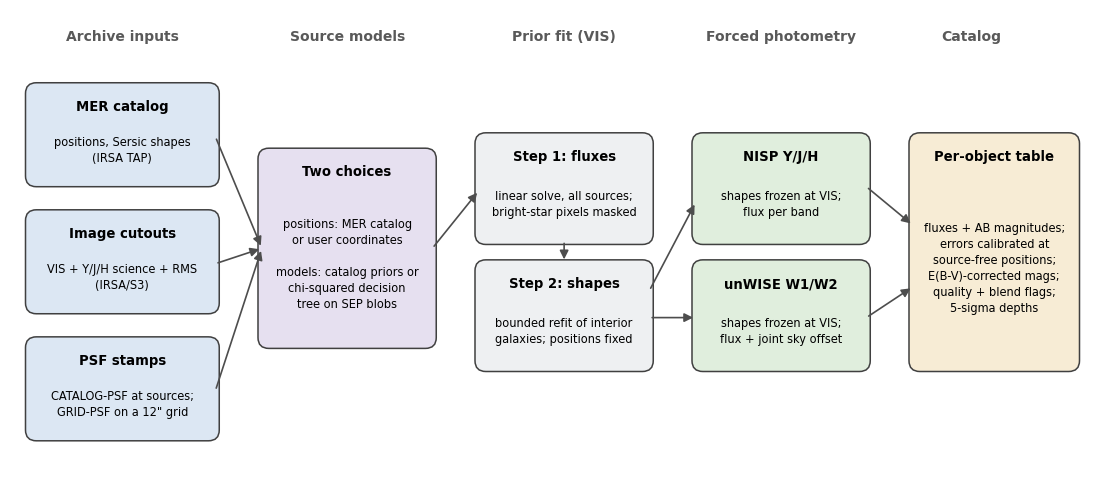

In [3]:
ep.viz.plot_workflow()
plt.show()


## 3. The MER catalog

The MER catalog provides positions, point-likeness probabilities, and
a single-Sersic morphological fit for every Q1 source. The cached
subset is read if present; otherwise the query is sent to the IRSA TAP
service.


In [4]:
mer_path = DATA_DIR / f"mer_catalog_{TARGET_RA:.4f}_{TARGET_DEC:.4f}_{int(CUTOUT_SIZE_ARCSEC)}.fits"
if mer_path.exists():
    mer_cat = Table.read(mer_path)
    print(f"loaded {len(mer_cat)} sources from {mer_path.name}")
else:
    half_size_deg = CUTOUT_SIZE_ARCSEC / 2.0 / 3600.0
    mer_cat = ep.query_mer_catalog(TARGET_RA, TARGET_DEC, half_size_deg)
    print(f"queried IRSA TAP: {len(mer_cat)} sources")


loaded 1120 sources from mer_catalog_269.4800_67.3000_200.fits


## 4. Fetching the Euclid cutouts

``fetch_cutout`` reads the cached FITS if present; otherwise the MER
tile is located through IRSA SIA and only the bytes covering the
requested region are read from S3, a few hundred MB rather than the
1.5 GB tile, then cached locally.


In [5]:
# Pull the MER FLG (quality) plane for the prior band only: it is what
# build_tractor_image reads to drop the coadd-fatal pixels, what
# section 5 turns into the STARSIGNAL bright-star mask, and what
# section 13 reads to flag sources that sit on bad pixels.
cutouts = {}
for band in ('VIS', 'Y', 'J', 'H'):
    cutouts[band] = ep.fetch_cutout(
        band, TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC,
        data_dir=DATA_DIR / "cutouts",
        with_flag=(band == PRIOR["band"]))

for band, c in cutouts.items():
    print(f"  {band}: shape={c.shape}, pixel scale={c.pixel_scale_arcsec:.3f} arcsec/pix")

# Keep every source whose center lands on the image. A boundary
# source's profile is clipped by the cutout (its photometry carries the
# `edge` flag, section 13), but its light must stay in the model:
# removed, it would be absorbed by whichever neighbors the fit can reach.
mer_cat = ep.trim_catalog_to_cutout(
    mer_cat, cutouts['VIS'].wcs, cutouts['VIS'].shape)
print(f"\non the image: {len(mer_cat)} sources")


  VIS: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  Y: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  J: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  H: shape=(2000, 2000), pixel scale=0.100 arcsec/pix

on the image: 1119 sources


The four bands of the same field, at their native resolutions.


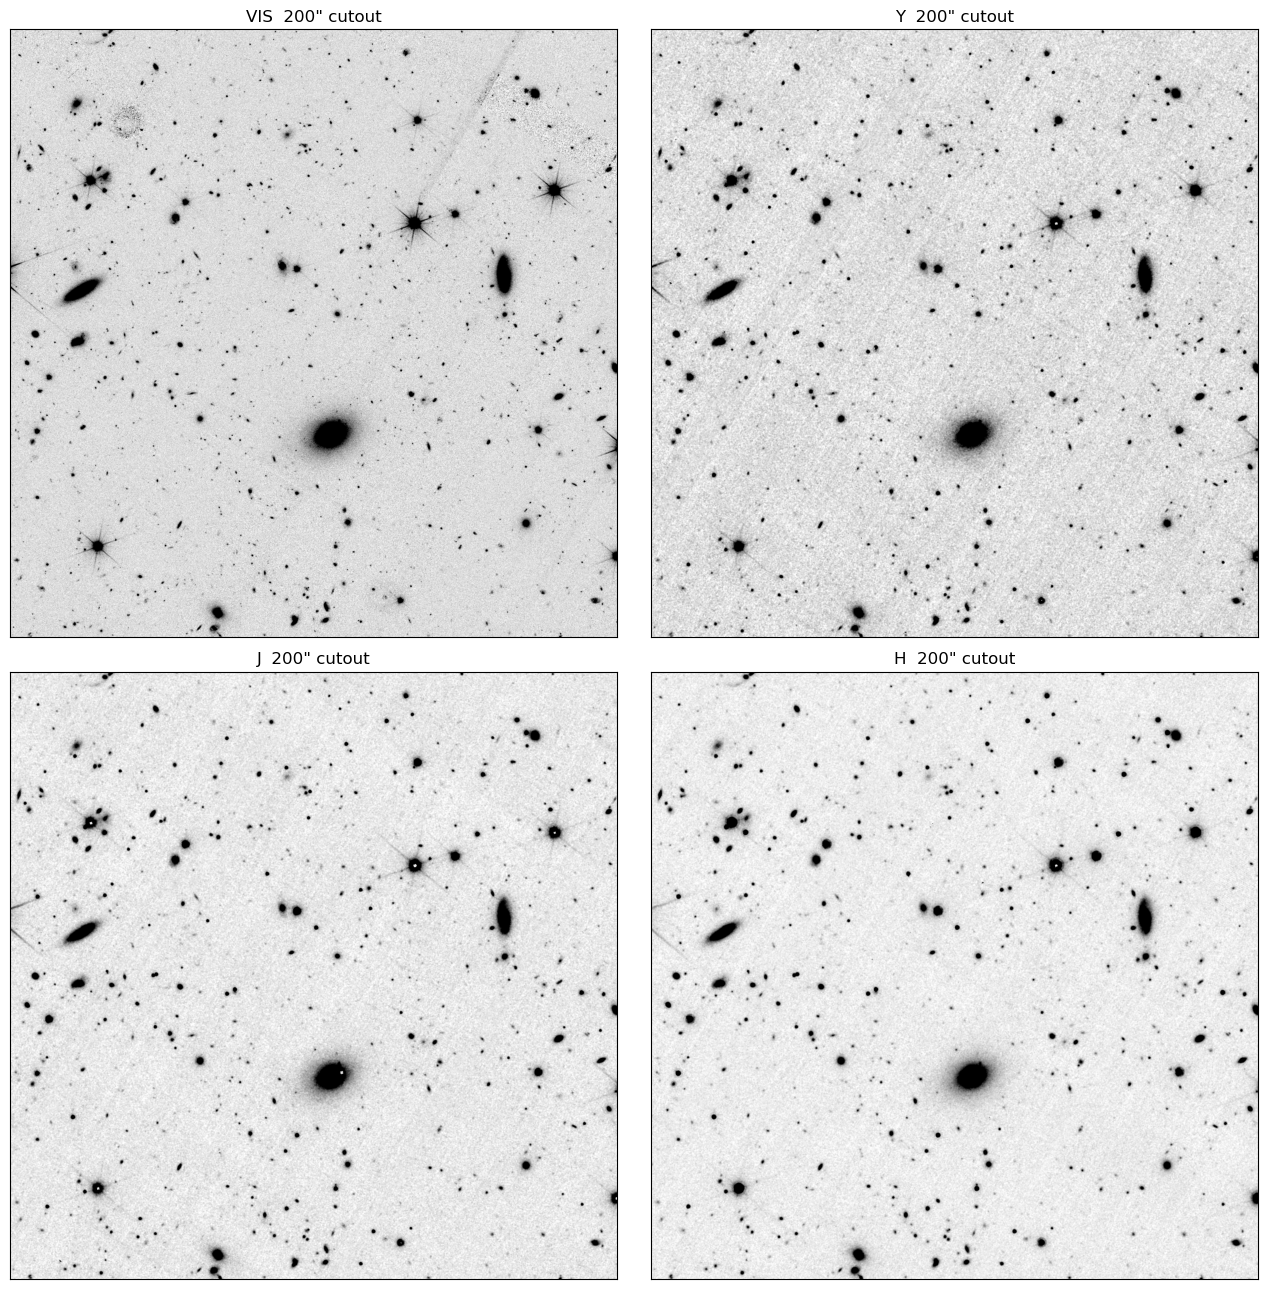

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, band in zip(axes.ravel(), ('VIS', 'Y', 'J', 'H')):
    ep.viz.show_cutout(cutouts[band], ax=ax,
                       title=f"{band}  {CUTOUT_SIZE_ARCSEC:.0f}\" cutout")
plt.tight_layout(); plt.show()


*All MER mosaics, including NISP, are resampled onto the common
0.1 arcsec VIS grid, so the four panels share the same pixel scale; the
bands differ in PSF (~0.2 arcsec FWHM in VIS, ~0.5 arcsec in NISP) and
depth.*


## 5. The VIS PSF and the Tractor image

Each MER tile ships its PSF model as 21x21 pixel stamps. This notebook
uses the GRID-PSF product, which samples the model on a regular
~12 arcsec grid across the tile. All stamps within 150 arcsec of the
target are extracted, so every position in the cutout has a stamp
within ~8.5 arcsec.


In [7]:
psf_data_vis = ep.extract_grid_psf(
    "VIS", TARGET_RA, TARGET_DEC, radius_arcsec=150.0,
    data_dir=DATA_DIR / "psf")
psf_stamp_vis, psf_fwhm_vis = ep.psf_summary(psf_data_vis)
print(f"VIS GRID-PSF: {len(psf_data_vis['stamps'])} stamps, "
      f"median FWHM = {psf_fwhm_vis:.3f} arcsec")

# Bright-star footprints (halos and diffraction spikes) carry real
# light the compact PSF stamp cannot model (section 12); read the MER
# STARSIGNAL flag bit as a pixel veto so that light stays out of the fit.
star_mask = ep.starsignal_pixel_mask(cutouts['VIS']) if MASK_BRIGHT_STARS else None
if star_mask is not None:
    print(f"STARSIGNAL bright-star mask: {int(star_mask.sum())} pixels "
          f"({100*star_mask.mean():.2f}%) excluded from the fit")

# build_tractor_image zeroes the inverse variance on the star mask and on
# the coadd-fatal FLG pixels (INVALID/SAT/NO_DATA); see section 13 for why
# the default is this narrow set and not every flagged pixel.
tim_vis = ep.build_tractor_image(cutouts['VIS'], psf_stamp_vis,
                                 pixel_mask=star_mask)
_flg = cutouts['VIS'].flag
if _flg is not None:
    _nbad = int(((_flg & ep.MER_VIS_BAD_BITS) != 0).sum())
    print(f"VIS FLG plane attached; {_nbad} pixel(s) carry coadd-fatal bits "
          f"(INVALID/SAT/NO_DATA) and are excluded from the fit.")


VIS GRID-PSF: 486 stamps, median FWHM = 0.198 arcsec
STARSIGNAL bright-star mask: 71368 pixels (1.78%) excluded from the fit
VIS FLG plane attached; 2430 pixel(s) carry coadd-fatal bits (INVALID/SAT/NO_DATA) and are excluded from the fit.


### The two MER PSF products: CATALOG-PSF and GRID-PSF

GRID-PSF samples the PSF model on a regular ~12 arcsec grid across
the tile, so no position is more than ~8.5 arcsec from a stamp. It
covers MER sources, user-supplied positions, and the
injected sources of notebook 03 alike, and is the product used
throughout this notebook. CATALOG-PSF provides one stamp per MER
source, at the source positions; it is the driver default for a MER
source list (``psf_product="auto"`` resolves to CATALOG-PSF for MER
sources and GRID-PSF for user coordinates). Both extractors return
the same structure, so downstream code is product-independent, and at
MER positions the two are interchangeable; the comparison below shows
the field-average stamps agree at the percent level.


GRID-PSF:    486 stamps on a regular grid, field FWHM = 0.198"
CATALOG-PSF: 2311 stamps at MER source positions, field FWHM = 0.198"


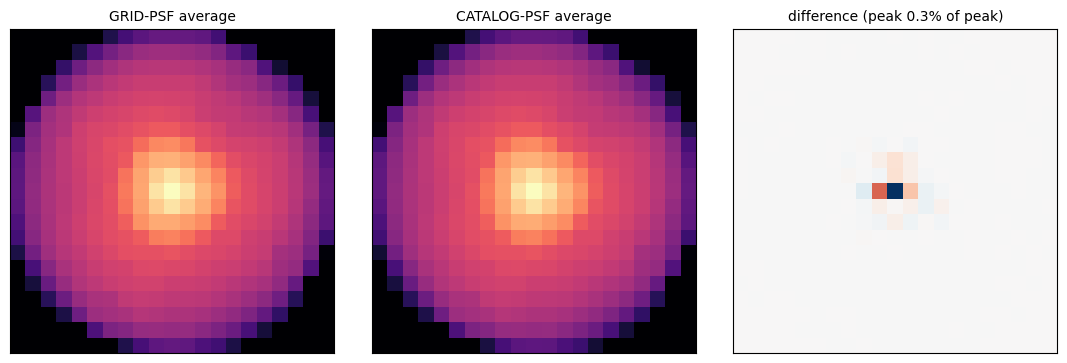

In [8]:
cat_vis = ep.extract_catalog_psf(
    'VIS', TARGET_RA, TARGET_DEC, radius_arcsec=150.0,
    data_dir=DATA_DIR / 'psf')
cat_stamp, cat_fwhm = ep.psf_summary(cat_vis)

print(f"GRID-PSF:    {len(psf_data_vis['stamps'])} stamps on a regular grid, "
      f"field FWHM = {psf_fwhm_vis:.3f}\"")
print(f"CATALOG-PSF: {len(cat_vis['stamps'])} stamps at MER source "
      f"positions, field FWHM = {cat_fwhm:.3f}\"")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, stamp, title in ((axes[0], psf_stamp_vis, 'GRID-PSF average'),
                         (axes[1], cat_stamp, 'CATALOG-PSF average')):
    ax.imshow(np.log10(np.maximum(stamp, 1e-7)), origin='lower',
              cmap='magma')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
diff = cat_stamp - psf_stamp_vis
v = np.abs(diff).max()
im = axes[2].imshow(diff, origin='lower', cmap='RdBu_r', vmin=-v, vmax=v)
axes[2].set_title(f'difference (peak {100 * v / psf_stamp_vis.max():.1f}% '
                  'of peak)', fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.tight_layout()
plt.show()

### Spatial coverage of the GRID-PSF

Stamp positions over the field, colored by FWHM, with the MER sources
and the cutout footprint overlaid; the 5th, 50th, and 95th-percentile
stamps are shown alongside. The grid covers the footprint
independently of where the catalog sources lie, and the FWHM
varies smoothly across the field (the stamps below span
~0.13-0.22 arcsec), so adjacent stamps differ little and the choice
of nearest stamp is not critical.


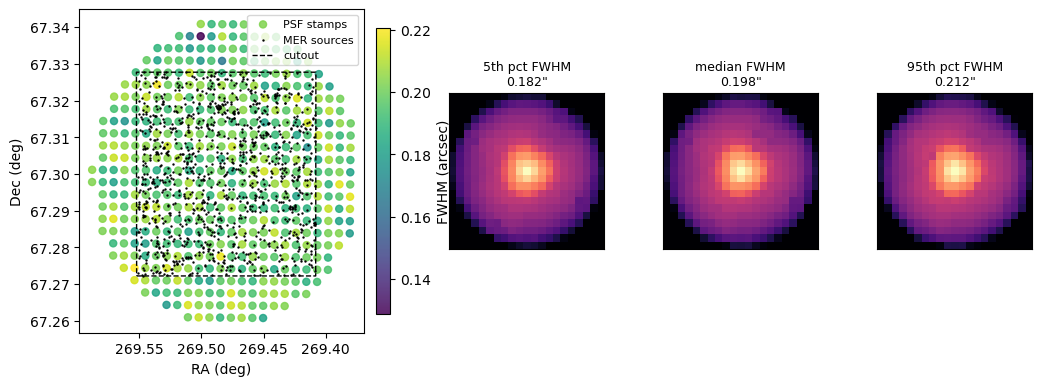

486 stamps on a regular grid, median spacing 12.0 arcsec
FWHM across the field: 0.129-0.221 arcsec (median 0.198)


In [9]:
fig, info = ep.viz.show_psf_grid(psf_data_vis, cutout=cutouts['VIS'],
                                 mer_cat=mer_cat)
plt.show()
print(f"{info['n_stamps']} stamps on a regular grid, median spacing "
      f"{info['median_spacing_arcsec']:.1f} arcsec")
print(f"FWHM across the field: {info['fwhm_min']:.3f}-"
      f"{info['fwhm_max']:.3f} arcsec (median {info['fwhm_median']:.3f})")


## 6. The source list

``PRIOR["objects"]`` fixes the positions (the MER catalog here);
``PRIOR["model_selection"]`` chooses the model class per source.

**``"prior"``**: assert the catalog class: ``PointSource`` for
point-like probability above 0.96 (the high-purity stellar cut) or
effective radius below the PSF half-width; ``SersicGalaxy`` with MER's
``n``, ``r_e``, and ellipticity otherwise.

**``"tree"``** (executed here): SEP defines blobs on the prior
image; the tree fits every blob member through the ladder
``PointSource -> SimpleGalaxy -> Exp -> Dev -> FixedCompositeGalaxy``
and keeps the lowest-chi-squared class (notebook 02). The source list
stays one-to-one with the input; a position with no detectable blob
keeps its prior model.

An explicit class (``"point"``, ``"sersic"``, ``"exp"``, ``"dev"``)
applies that model to every source.


In [10]:
t0 = time.time()
if PRIOR["model_selection"] == "tree":
    print("Running the chi-squared decision tree on the prior image...")
    # The default selector fits every blob member with the full model
    # ladder and takes the lowest chi-squared outright; calibrated on
    # this data. A guarded free-n Sersic tier is added for bright
    # resolved sources, kept only when it improves the chi-squared.
    sources_list, _ = ep.run_model_selection(
        mer_cat, tim_vis,
        cutouts[PRIOR["band"]].data, tim_vis.getInvvar(),
        pixscale_arcsec=cutouts[PRIOR["band"]].pixel_scale_arcsec,
        n_workers=N_WORKERS,
    )
    # Rows the tree could not place fall back to their MER prior.
    fallback = ep.build_sources_from_mer(
        mer_cat, band=PRIOR["band"], psf_fwhm_arcsec=psf_fwhm_vis)
    sources = [s if s is not None else fb
               for s, fb in zip(sources_list, fallback)]
else:  # model_selection == "prior"
    print("Using the MER continuous-Sersic catalog priors.")
    sources = ep.build_sources_from_mer(
        mer_cat, band=PRIOR["band"], psf_fwhm_arcsec=psf_fwhm_vis)

class_hist = {}
for s in sources:
    class_hist[type(s).__name__] = class_hist.get(type(s).__name__, 0) + 1
print(f"\nbuilt {len(sources)} sources in {time.time()-t0:.1f} s")
for k in sorted(class_hist):
    print(f"  {k:<22s} {class_hist[k]}")


Running the chi-squared decision tree on the prior image...


/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/tractor/galaxy.py:789: RuntimeWarning: overflow encountered in exp
  return 1. / (1 + np.exp(4. * (0.5 - f)))



built 1119 sources in 164.0 s
  DevGalaxy              109
  ExpGalaxy              562
  FixedCompositeGalaxy   191
  PointSource            163
  SersicGalaxy           74
  SimpleGalaxy           20


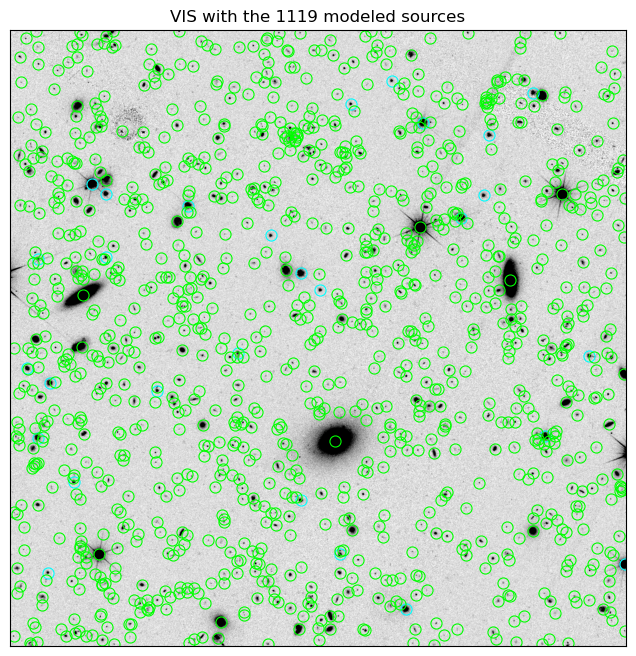

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ep.viz.show_cutout(cutouts['VIS'], mer_cat, ax=ax,
                   title=f"VIS with the {len(sources)} modeled sources")
plt.show()


*The modeled source list over the VIS prior image: cyan circles are
stars, green circles galaxies, following the MER classifier.*


## 7. Step 1: flux-only forced photometry

All parameters except brightness are held fixed, and Tractor solves for
the flux that best matches each source's PSF-convolved model to the
pixels. Sources whose fitted flux is negative, or grossly discrepant
with the MER reference, are flagged and held fixed in step 2.


In [12]:
initial_vis_ujy = np.asarray(mer_cat['flux_vis_sersic'], dtype=float)
tractor_vis, fit_quality, vis_err_ujy = ep.fit_forced_photometry(
    tim_vis, sources, band='VIS',
    initial_fluxes_ujy=initial_vis_ujy, return_errors=True,
)
print(f"Step 1 done; {int(fit_quality.sum())}/{len(sources)} sources good.")
print(f"median formal 1-sigma flux error (flux-only fit): "
      f"{np.nanmedian(vis_err_ujy[fit_quality]):.3f} microJansky")


Step 1 done; 1113/1119 sources good.
median formal 1-sigma flux error (flux-only fit): 0.020 microJansky


## 8. Step 2: free shapes for interior galaxies

For galaxies more than 50 pixels from the cutout edges, the shape
parameters (including the Sersic ``n``) are re-optimized jointly with
brightness; positions remain fixed. The step is skipped when
``free_shapes`` is ``False``, and always in the decision-tree path:
the tree has already fitted each blob's shapes with the bounded
optimizer and shapes stay frozen thereafter.


In [13]:
if PRIOR["free_shapes"] and PRIOR["model_selection"] != "tree":
    fit_quality, n_thawed = ep.fit_free_shapes(
        tractor_vis, tim_vis, sources, fit_quality,
        band=PRIOR["band"], initial_fluxes_ujy=initial_vis_ujy,
    )
    print(f"Step 2 thawed shapes for {n_thawed} galaxies; "
          f"{int(fit_quality.sum())}/{len(sources)} sources still good.")
else:
    n_thawed = 0
    reason = ("the decision tree has already fit each blob's shapes with "
              "the bounded optimizer; they stay frozen"
              if PRIOR["model_selection"] == "tree"
              else "PRIOR['free_shapes']=False; shapes stay at the prior")
    print(f"Skipping step 2: {reason}.")

# Optional: a bounded recenter on the prior band. The refined positions live on
# the source objects, so the later NISP/unWISE forced fits measure every band at
# the same recentered position; the multi-band astrometry stays shared.
if PRIOR.get("refine_positions"):
    fit_quality, n_refined, pos_shift_arcsec = ep.refine_positions(
        tractor_vis, tim_vis, sources, fit_quality, band=PRIOR["band"])
    _moved = pos_shift_arcsec[pos_shift_arcsec > 0]
    msg = (f"median shift {np.median(_moved) * 1000:.0f} mas"
           if len(_moved) else "no source exceeded the noise")
    print(f"Refined {n_refined} positions (bounded to 0.2 arcsec); {msg}.")
else:
    pos_shift_arcsec = np.zeros(len(sources))
    print("Position refinement off (PRIOR['refine_positions']=False); "
          "centroids stay fixed at the prior.")

Skipping step 2: the decision tree has already fit each blob's shapes with the bounded optimizer; they stay frozen.
Position refinement off (PRIOR['refine_positions']=False); centroids stay fixed at the prior.


### Re-extracting fluxes with each source's own PSF

The two fitting steps used a single field-average PSF stamp. That is
the right choice for the joint solve, but across a VIS field the PSF FWHM
varies by ~15 percent, so a compact source whose local PSF is sharper
or broader than the average has its flux mis-estimated at the percent
level. The fluxes are therefore re-extracted once per PSF group,
holding positions and shapes frozen, with each group fit through its
nearest GRID-PSF stamp (section 5); the CATALOG-PSF stamps are
interchangeable here, since the two products share one layout. This
is the same re-extraction the one-call driver performs
(``psf_product="grid"``), and the re-extracted values are the ones
exported to the catalog.

In [14]:
_flux_before = np.array(
    [s.brightness.getFlux('VIS') for s in sources]) * 3.631
_flux_psf, _err_psf, _n_groups = ep.refit_fluxes_persource_psf(
    sources, cutouts['VIS'], psf_data_vis, band='VIS',
    n_workers=N_WORKERS,
    # Re-apply the bright-star pixel veto: without it this step would
    # re-admit the halo and spike pixels excluded from the joint fit and
    # bias the re-extracted fluxes of sources near bright stars.
    pixel_mask=star_mask)
vis_err_ujy = np.where(np.isfinite(_err_psf), _err_psf, vis_err_ujy)
with np.errstate(invalid='ignore', divide='ignore'):
    _moved = np.abs(_flux_psf / np.where(_flux_before != 0,
                                         _flux_before, np.nan) - 1)
print(f"re-extracted {len(sources)} fluxes in {_n_groups} PSF groups; "
      f"median |flux change| = {100 * np.nanmedian(_moved):.2f}%, "
      f"90th percentile = {100 * np.nanpercentile(_moved, 90):.2f}%")

re-extracted 1119 fluxes in 64 PSF groups; median |flux change| = 0.16%, 90th percentile = 0.82%


## 9. VIS data, model, and residual

Two views: (data - model) scaled to +/- 5 formal sigma, and
chi = (data - model) * sqrt(invvar), which is N(0,1) for a perfect
fit with uncorrelated noise.

Two properties of forced photometry set the residual floor:

1. **Positions are frozen at the prior** and shared across bands, so
   resolved galaxies keep a faint residual from arms, bars, and clumps
   that no smooth profile reproduces.
2. **The PSF stamp is truncated** (+/- 1 arcsec): it carries a point
   source's core, not its spikes or halo. The STARSIGNAL mask (gray
   pixels, with the coadd-fatal FLG pixels) removes that stellar light
   from the fit; the covered stars are not measured, and their light
   cannot bias neighbors.

The chi map is close to N(0,1) on source-free pixels.


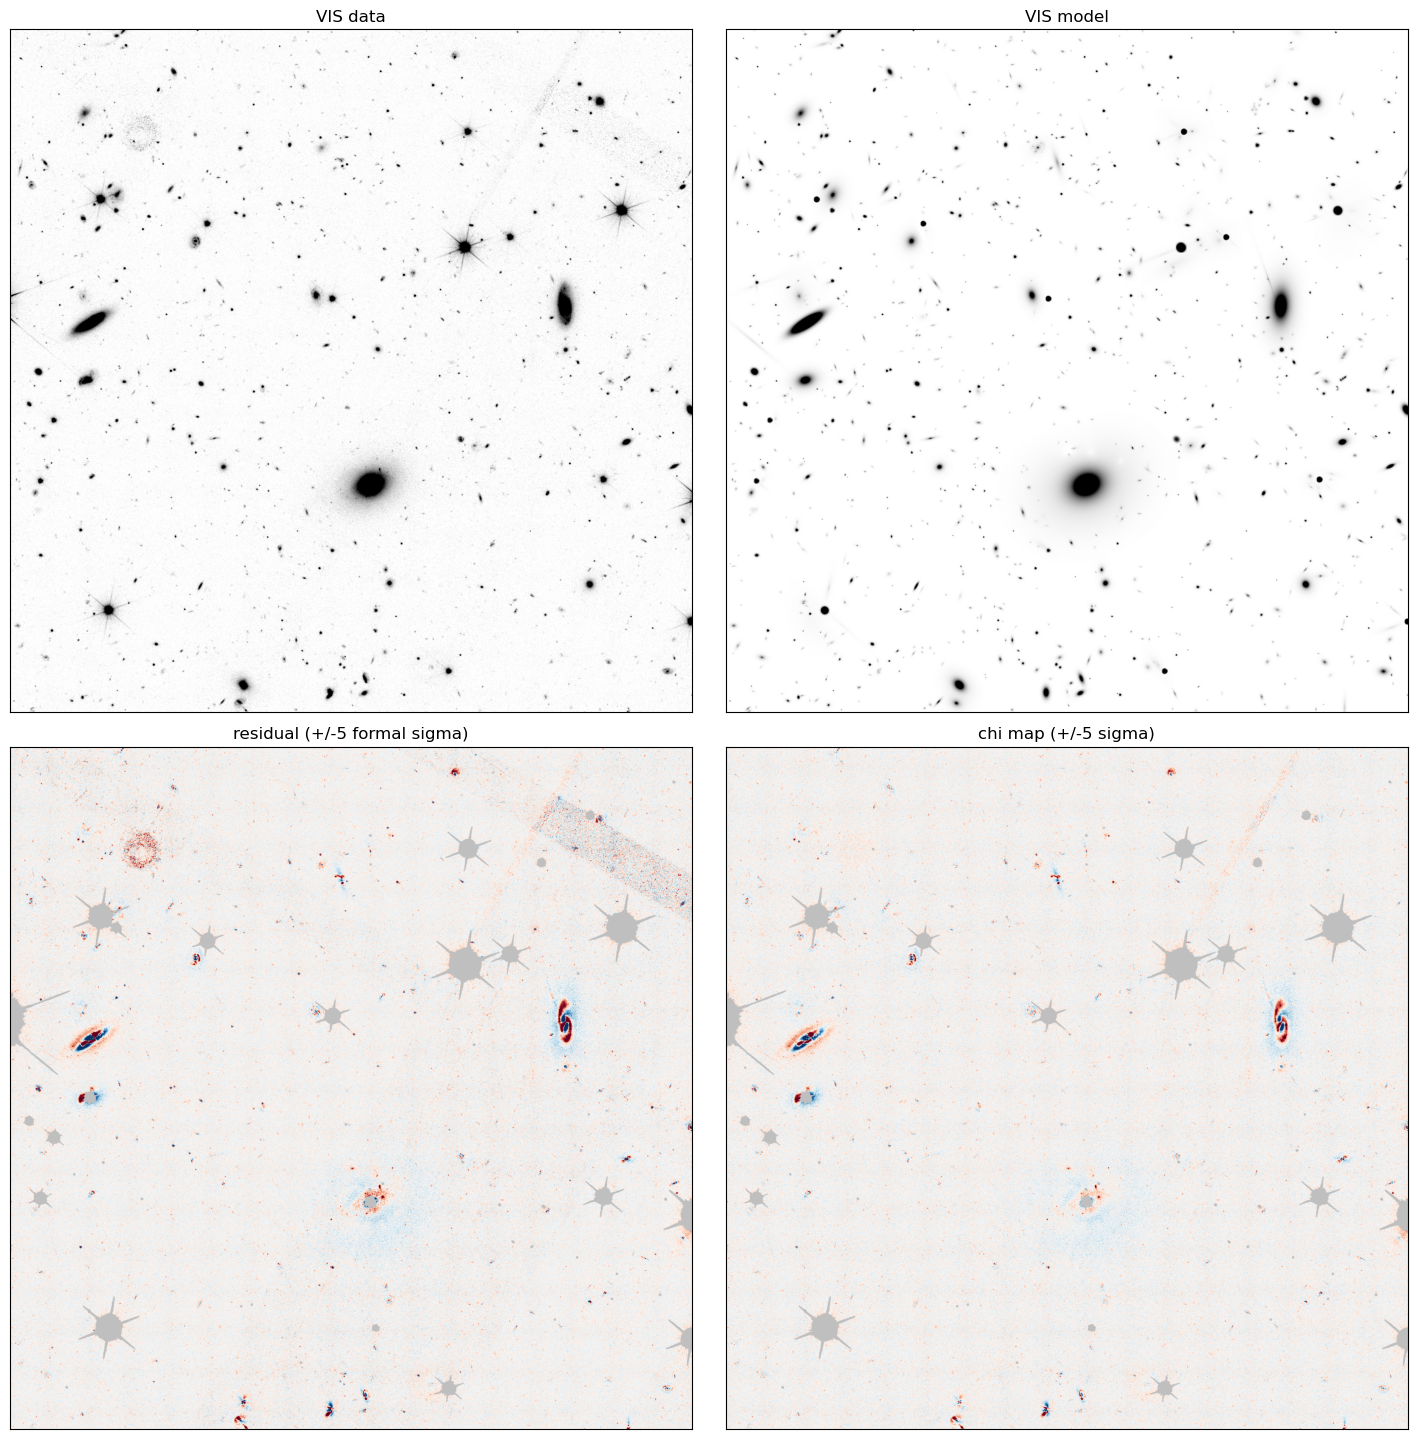

VIS formal per-pixel sigma:    0.0037004 counts
VIS empirical residual sigma:  0.0017891 counts
VIS chi std:                   0.557 (below 1 is expected on a resampled coadd; see section 14)


In [15]:
res = ep.measure_residual(tractor_vis, tim_vis)
invvar_vis = tim_vis.getInvvar()

fig, axes = plt.subplots(2, 2, figsize=(14.5, 14.5))
vmax = float(np.nanpercentile(res['data'], 99.5))
axes[0, 0].imshow(res['data'],  origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[0, 0].set_title('VIS data')
axes[0, 1].imshow(res['model'], origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[0, 1].set_title('VIS model')
_, info_vis_res = ep.viz.show_residual(
    res['data'], res['model'], invvar=invvar_vis,
    ax=axes[1, 0], title='residual (+/-5 formal sigma)')
_, info_vis_chi = ep.viz.show_chi_map(
    res['data'], res['model'], invvar_vis,
    ax=axes[1, 1], title='chi map (+/-5 sigma)')
for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print(f"VIS formal per-pixel sigma:    {info_vis_res['formal_sigma']:.5g} counts")
print(f"VIS empirical residual sigma:  {info_vis_res['residual_std']:.5g} counts")
# The MER mosaics are resampled coadds: the per-pixel noise is correlated,
# so a perfect fit gives a chi std below 1 here (section 14 measures the
# flux-error consequence).
print(f"VIS chi std:                   {info_vis_chi['chi_std']:.3f} "
      f"(below 1 is expected on a resampled coadd; see section 14)")

## 10. VIS: Tractor versus MER

The Tractor fluxes are the two-step fit on whichever models
``PRIOR["objects"]`` selected (the tree classes in this run). One
deliberate asymmetry: this fit excludes the STARSIGNAL footprints,
while Q1 flags the sources inside its bright-star masks
(``det_quality_flag``) rather than excluding the pixels. Sources near
a bright star are therefore set aside as a precaution, drawn as open
gray symbols (the section 13 flags) and left out of the medians; on
this field their median ratio matches the clean subset.


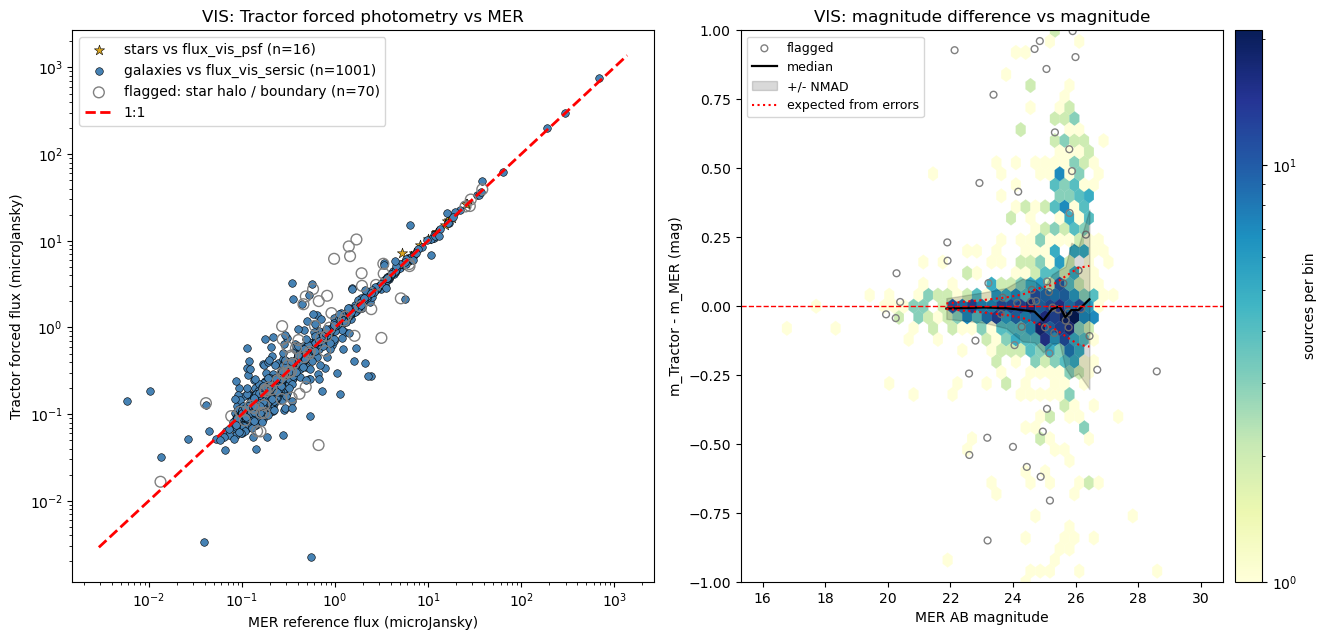

galaxies: median(Tractor / MER_sersic) = 1.010  (excluding flagged bright-star regions: 1.009, n=1001)
median and NMAD of m_Tractor - m_MER in equal-count magnitude bins:
  21.87 mag: median -0.008, NMAD 0.038
  23.09 mag: median -0.004, NMAD 0.055
  23.78 mag: median -0.007, NMAD 0.073
  24.30 mag: median -0.014, NMAD 0.114
  24.68 mag: median -0.019, NMAD 0.111
  24.96 mag: median -0.051, NMAD 0.116
  25.25 mag: median -0.010, NMAD 0.125
  25.49 mag: median -0.001, NMAD 0.133
  25.67 mag: median -0.040, NMAD 0.184
  25.86 mag: median -0.014, NMAD 0.244
  26.09 mag: median -0.014, NMAD 0.229
  26.44 mag: median +0.025, NMAD 0.326


In [16]:
tractor_vis_ujy = np.array(
    [s.brightness.getFlux('VIS') for s in sources]) * 3.631
is_star = np.asarray(mer_cat['is_star'], dtype=bool)
ref_star = np.asarray(mer_cat['flux_vis_psf'],    dtype=float)
ref_gal  = np.asarray(mer_cat['flux_vis_sersic'], dtype=float)

# Bright stars and their close neighbors carry unmodeled spike/halo
# light on both axes, and a source at the cutout boundary is measured
# from a clipped profile; flag both (same flags as section 13) so the
# plot and medians separate them. probable_bright_stars also covers the
# brightest stars, on which the classifier abstains.
flags9 = ep.flag_sources(
    np.asarray(mer_cat['ra']), np.asarray(mer_cat['dec']),
    tractor_vis_ujy, ep.probable_bright_stars(mer_cat),
    wcs=cutouts['VIS'].wcs, shape=cutouts['VIS'].shape)
contam = ~np.asarray(flags9['reliable'])

# A nan flux error means the masked fit never constrained the source
# (a fully masked bright star frozen at its seed): not a measurement,
# so it does not enter the comparison at all.
measured = np.isfinite(vis_err_ujy)
m_s = fit_quality & measured & is_star  & (ref_star > 0) & (tractor_vis_ujy > 0)
m_g = fit_quality & measured & ~is_star & (ref_gal  > 0) & (tractor_vis_ujy > 0)

fig, (ax, axd) = plt.subplots(1, 2, figsize=(13.5, 6.5))
ax.scatter(ref_star[m_s & ~contam], tractor_vis_ujy[m_s & ~contam],
           c='goldenrod', marker='*', s=60, edgecolors='k', linewidths=0.4,
           label=f'stars vs flux_vis_psf (n={int((m_s & ~contam).sum())})')
ax.scatter(ref_gal[m_g & ~contam], tractor_vis_ujy[m_g & ~contam],
           c='steelblue', s=30, edgecolors='k', linewidths=0.4,
           label=f'galaxies vs flux_vis_sersic (n={int((m_g & ~contam).sum())})')
_xc = np.where(is_star, ref_star, ref_gal)
_mc = (m_s | m_g) & contam
ax.scatter(_xc[_mc], tractor_vis_ujy[_mc], facecolors='none',
           edgecolors='0.5', s=60, linewidths=1.0,
           label=f'flagged: star halo / boundary (n={int(_mc.sum())})')
all_x = np.concatenate([ref_star[m_s], ref_gal[m_g]])
if len(all_x):
    ax.plot([all_x.min()*0.5, all_x.max()*2],
            [all_x.min()*0.5, all_x.max()*2],
            'r--', lw=2, label='1:1')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('MER reference flux (microJansky)')
ax.set_ylabel('Tractor forced flux (microJansky)')
ax.legend()
ax.set_title('VIS: Tractor forced photometry vs MER')

# Magnitude difference vs magnitude with the running median, the NMAD,
# and the scatter expected from the two pipelines' reported errors; the
# same helper draws the NISP comparison in section 16.
ref = np.where(is_star, ref_star, ref_gal)
sel = m_s | m_g
_em_psf = np.ma.filled(np.ma.asarray(mer_cat['fluxerr_vis_psf'], float), np.nan)
_em_ser = np.ma.filled(np.ma.asarray(mer_cat['fluxerr_vis_sersic'], float), np.nan)
err_mer = np.where(is_star, _em_psf, _em_ser)
_, dstat = ep.viz.show_dmag_vs_mag(
    ref, tractor_vis_ujy, err_ujy=vis_err_ujy, ref_err_ujy=err_mer,
    sel=sel & ~contam, flagged=sel & contam, ax=axd,
    xlabel='MER AB magnitude', ylabel='m_Tractor - m_MER (mag)',
    title='VIS: magnitude difference vs magnitude')
axd.legend(fontsize=9)
plt.tight_layout(); plt.show()

med_g = float(np.median(tractor_vis_ujy[m_g] / ref_gal[m_g]))
m_gc = m_g & ~contam
med_gc = float(np.median(tractor_vis_ujy[m_gc] / ref_gal[m_gc]))
print(f"galaxies: median(Tractor / MER_sersic) = {med_g:.3f}  "
      f"(excluding flagged bright-star regions: {med_gc:.3f}, n={int(m_gc.sum())})")
print("median and NMAD of m_Tractor - m_MER in equal-count magnitude bins:")
for c, m, s in zip(dstat['centers'], dstat['median'], dstat['nmad']):
    print(f"  {c:5.2f} mag: median {m:+.3f}, NMAD {s:.3f}")


*The median ratio lies within a few percent of unity and is unchanged
when the flagged bright-star regions are excluded: the contamination
affects individual sources, not the ensemble. The right panel shows
the magnitude difference against magnitude with the running median,
the NMAD, and the scatter expected from the two pipelines' reported
errors (dotted); the NMAD tracking the expected curve at the faint end
shows the growth of the scatter is the photon noise itself.*


## 11. Examples of fitted sources

Six example galaxies at 5-20 microJansky, selected by criteria in
the cell (measured, unflagged, interior) and spread across the
flux window; the chosen rows are printed below. The structured cases, clumpy and irregular
galaxies no smooth profile can match, are treated in section 12. The
panels show the final fitted scene (every neighbor inside a stamp is
part of the simultaneous model) with the data, the model, the
residual on the formal noise scale, and the chi map. The printed core
residual, as a fraction of the model peak, reads the same maps in
units of the light rather than the noise.


Whole-field chi: std=0.56, 0.16% of pixels |chi|>3 (consistent with noise in aggregate).
Showing 6 example galaxies:
  row   45  S/N=  141  MER   5.11 uJy  Tractor   5.14 uJy  ratio=1.01  core chi RMS=2.18  core residual peak=16% of model peak (noise alone: 0%)
  row   92  S/N=  128  MER   5.67 uJy  Tractor   5.64 uJy  ratio=0.99  core chi RMS=1.00  core residual peak=12% of model peak (noise alone: 2%)
  row  557  S/N=   81  MER   6.35 uJy  Tractor  15.06 uJy  ratio=2.37  core chi RMS=1.54  core residual peak=46% of model peak (noise alone: 10%)
  row  167  S/N=  105  MER   7.41 uJy  Tractor   7.17 uJy  ratio=0.97  core chi RMS=1.67  core residual peak=51% of model peak (noise alone: 8%)
  row   46  S/N=  216  MER  11.49 uJy  Tractor  10.77 uJy  ratio=0.94  core chi RMS=0.82  core residual peak=5% of model peak (noise alone: 1%)
  row  205  S/N=  178  MER  18.68 uJy  Tractor  18.94 uJy  ratio=1.01  core chi RMS=0.75  core residual peak=19% of model peak (noise alone: 8%)


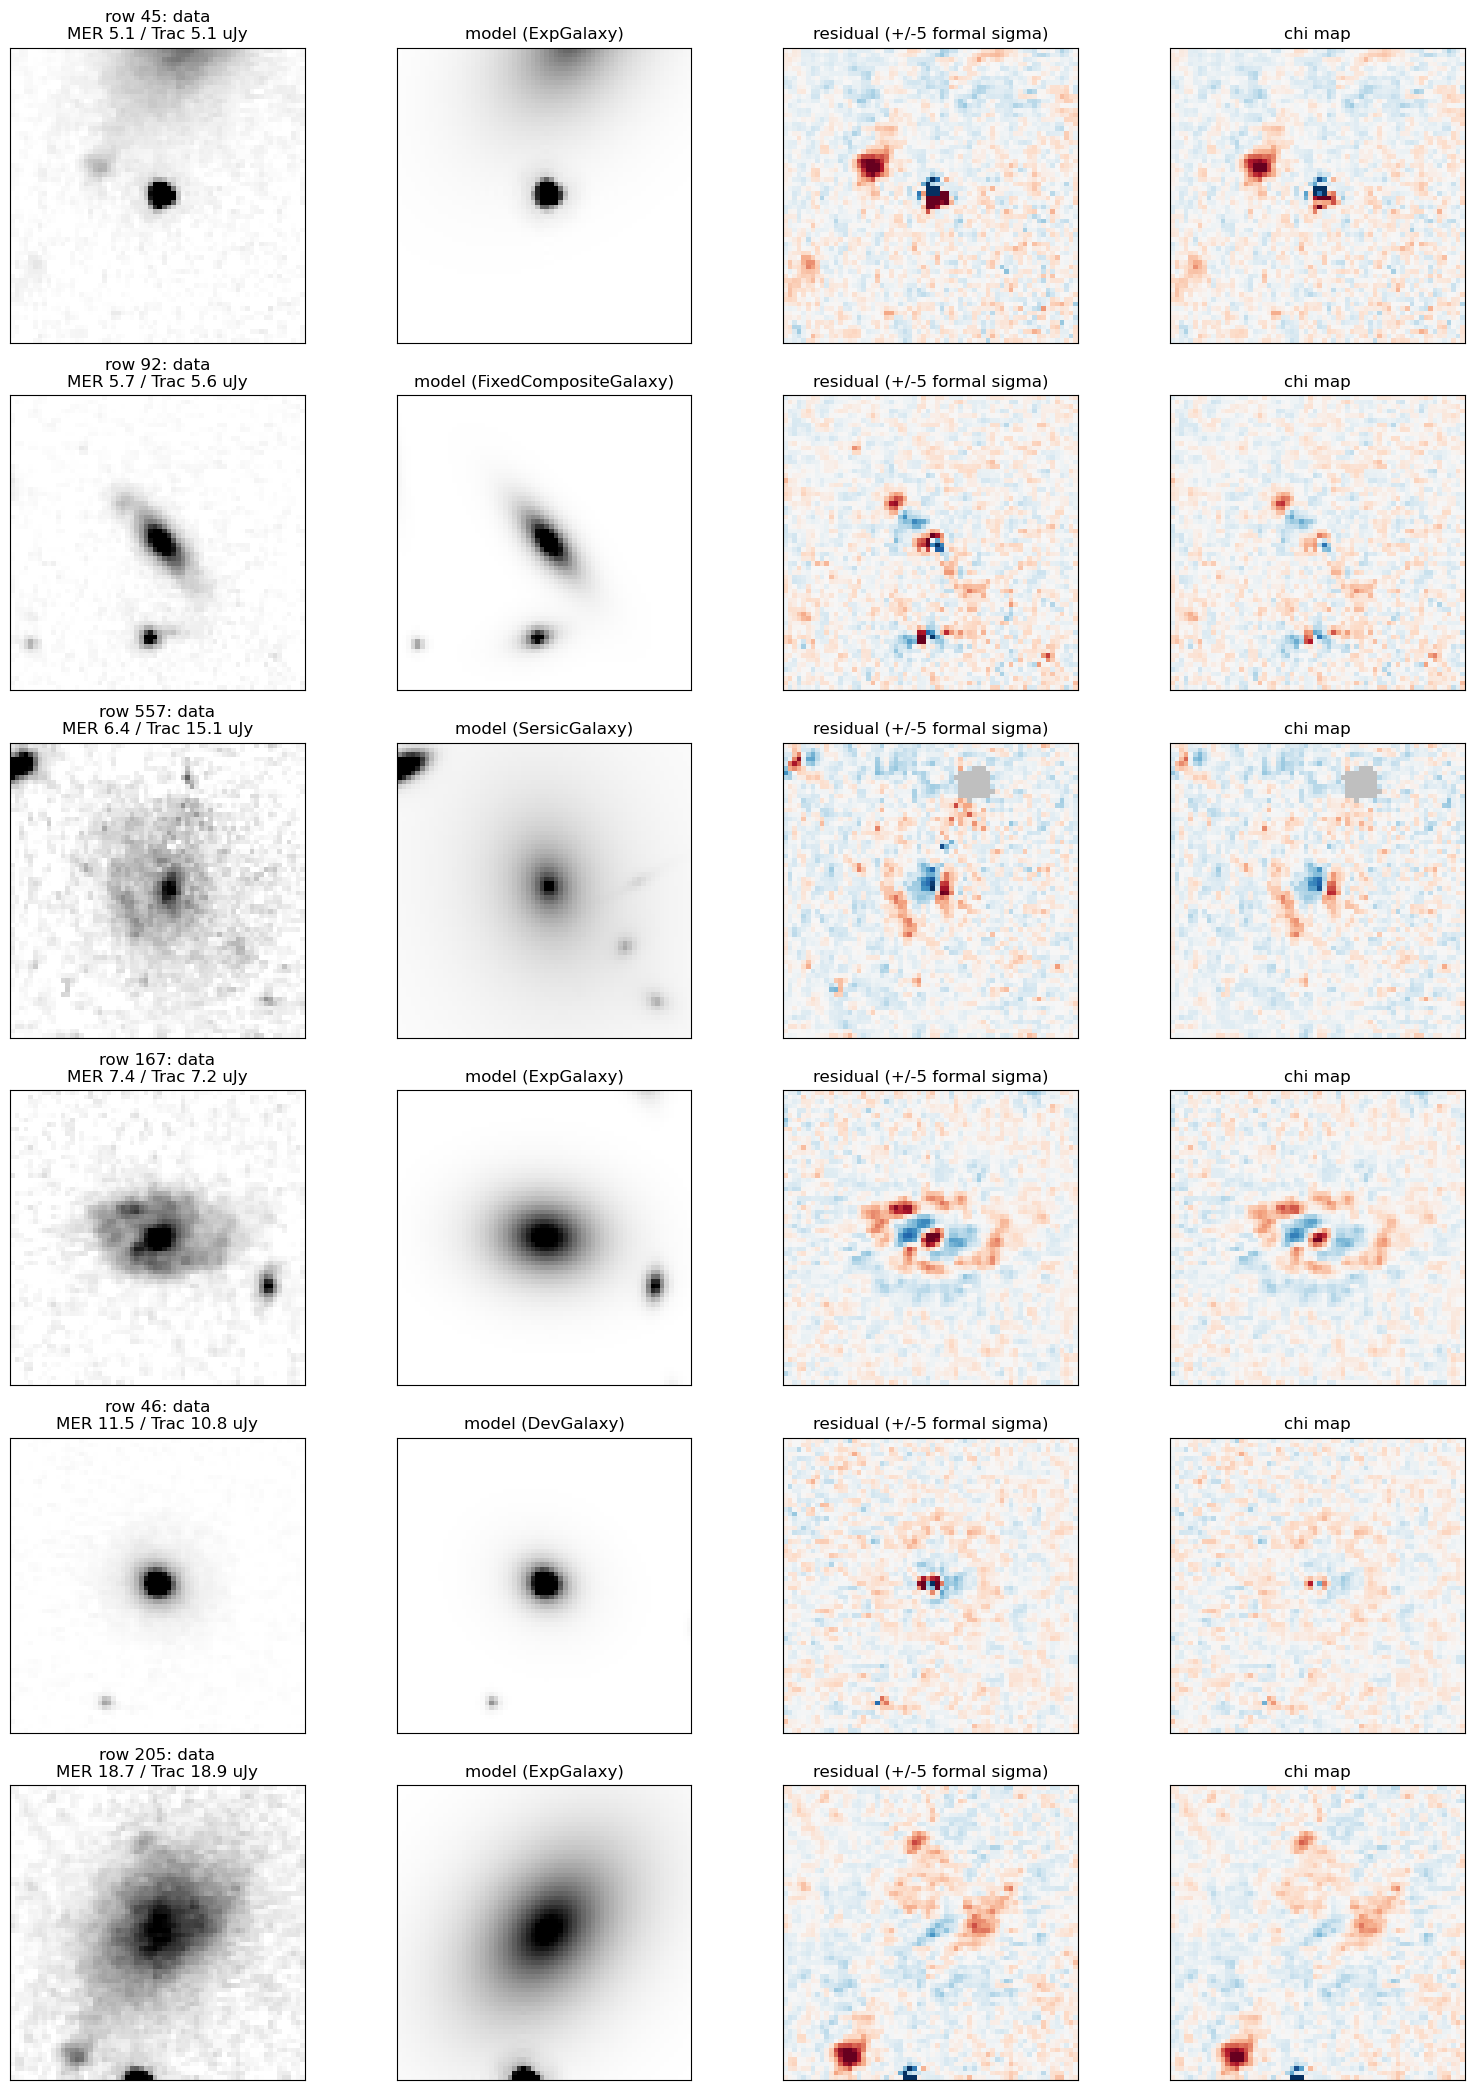

In [17]:
# Six interior example galaxies at 5-20 microJansky (S/N ~ 100-200),
# selected by criteria rather than fixed row numbers so the same cell
# works across catalog releases: measured, unflagged galaxies far enough
# from the boundary for a full stamp, spread evenly across the flux
# window. The stamps render the final full-field model, so neighbors
# are modeled as well. Reuses section 10's arrays (tractor_vis_ujy,
# is_star, ref_star, ref_gal, contam, measured).
ref = np.where(is_star, ref_star, ref_gal)
ratio = np.divide(tractor_vis_ujy, ref,
                  out=np.full(len(ref), np.nan), where=ref > 0)

full_model = tractor_vis.getModelImage(0)
full_data = tim_vis.getImage()
full_invvar = tim_vis.getInvvar()

# Whole-field chi over every valid pixel.
_chi_field = (full_data - full_model) * np.sqrt(np.where(full_invvar > 0, full_invvar, 0))
_sky = full_invvar > 0
print(f"Whole-field chi: std={np.std(_chi_field[_sky]):.2f}, "
      f"{100 * (np.abs(_chi_field[_sky]) > 3).mean():.2f}% of pixels |chi|>3 "
      f"(consistent with noise in aggregate).")

CUT_PIX = 64   # stamp side: +/- 32 pixels = ~6.4 arcsec
CORE = 6       # core half-side around the source: ~1.2 arcsec across

_px, _py = cutouts['VIS'].wcs.world_to_pixel_values(
    np.asarray(mer_cat['ra'], float), np.asarray(mer_cat['dec'], float))
_H, _W = cutouts['VIS'].shape
_interior = ((_px > CUT_PIX) & (_px < _W - CUT_PIX)
             & (_py > CUT_PIX) & (_py < _H - CUT_PIX))
_cand = np.flatnonzero(fit_quality & measured & ~is_star & ~contam
                       & _interior & (ref >= 5.0) & (ref <= 20.0))
_cand = _cand[np.argsort(ref[_cand])]
good_idx = _cand[np.unique(np.linspace(0, len(_cand) - 1,
                                       min(6, len(_cand))).round().astype(int))]

def _stamp(i):
    """(sl_y, sl_x, cy, cx): stamp slices and the source position inside
    the stamp (edge-safe: a clipped stamp keeps the true center)."""
    px, py = tim_vis.getWcs().positionToPixel(sources[i].getPosition())
    px, py = int(round(px)), int(round(py))
    sl_y = slice(max(0, py - CUT_PIX // 2),
                 min(full_data.shape[0], py + CUT_PIX // 2))
    sl_x = slice(max(0, px - CUT_PIX // 2),
                 min(full_data.shape[1], px + CUT_PIX // 2))
    return sl_y, sl_x, py - sl_y.start, px - sl_x.start

def _core_stats(i):
    """Core chi RMS, max |residual| / model peak, and the same ratio for
    pure noise (the floor the measured fraction should be read against)."""
    sl_y, sl_x, cy, cx = _stamp(i)
    d = full_data[sl_y, sl_x]; m = full_model[sl_y, sl_x]; iv = full_invvar[sl_y, sl_x]
    cs = (slice(max(0, cy - CORE), cy + CORE), slice(max(0, cx - CORE), cx + CORE))
    dd, mm, vv = d[cs], m[cs], iv[cs]
    good = vv > 0
    if good.sum() < 20:
        return np.nan, np.nan, np.nan
    chi = (dd - mm)[good] * np.sqrt(vv[good])
    rms = float(np.sqrt(np.mean(chi ** 2)))
    peak = max(float(mm.max()), 1e-12)
    frac = float(np.max(np.abs(dd - mm)[good]) / peak)
    noise_frac = float(np.median(1.0 / np.sqrt(vv[good])) / peak)
    return rms, frac, noise_frac

with np.errstate(invalid='ignore', divide='ignore'):
    _snr = tractor_vis_ujy / vis_err_ujy

print(f"Showing {len(good_idx)} example galaxies:")
for i in good_idx:
    rms, frac, nfrac = _core_stats(i)
    print(f"  row {i:4d}  S/N={_snr[i]:5.0f}  MER {ref[i]:6.2f} uJy  "
          f"Tractor {tractor_vis_ujy[i]:6.2f} uJy  ratio={ratio[i]:.2f}  "
          f"core chi RMS={rms:.2f}  core residual peak="
          f"{100 * frac:.0f}% of model peak (noise alone: {100 * nfrac:.0f}%)")

fig, axes = plt.subplots(len(good_idx), 4,
                          figsize=(16, 3.5 * len(good_idx)))
if len(good_idx) == 1:
    axes = axes[np.newaxis, :]
for row, i in enumerate(good_idx):
    sl_y, sl_x, cy, cx = _stamp(i)
    d = full_data[sl_y, sl_x]
    m = full_model[sl_y, sl_x]
    iv = full_invvar[sl_y, sl_x]
    vmax = float(np.nanpercentile(d, 99.5))
    axes[row, 0].imshow(d, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    axes[row, 0].set_title(
        f"row {i}: data\nMER {ref[i]:.1f} / Trac {tractor_vis_ujy[i]:.1f} uJy")
    axes[row, 1].imshow(m, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    axes[row, 1].set_title(f"model ({type(sources[i]).__name__})")
    ep.viz.show_residual(d, m, invvar=iv, ax=axes[row, 2],
                         title='residual (+/-5 formal sigma)')
    ep.viz.show_chi_map(d, m, iv, ax=axes[row, 3],
                        title='chi map')
    for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


### Structured residuals and the total flux

The residual maps above show what no smooth profile can absorb: arms,
bars, and clumps. The question that matters for the catalog is whether
that structure costs *total flux*. For every measured, unflagged
galaxy the cell below sums the residual inside a per-source aperture
(3 r_e, clipped to 0.8-3.0 arcsec) and expresses it as a fraction of
the fitted flux -- the light the model failed to capture, measured
without reference to any other catalog. Sources with a neighbor inside
the aperture (plus 0.5 arcsec) are excluded so the sum is attributable
to one source, and a per-source noise estimate on the fraction
separates structure from sky noise.


88 isolated galaxies above 2 uJy; median aperture noise on the fraction: 1.0%
missed-light fraction: median +0.4%, 68% within 2.0%, max |f_res| 29.1%
structure detected (|f_res| > 3 sigma): 16/88
median Tractor/MER: smooth half 1.001, structured half 1.003


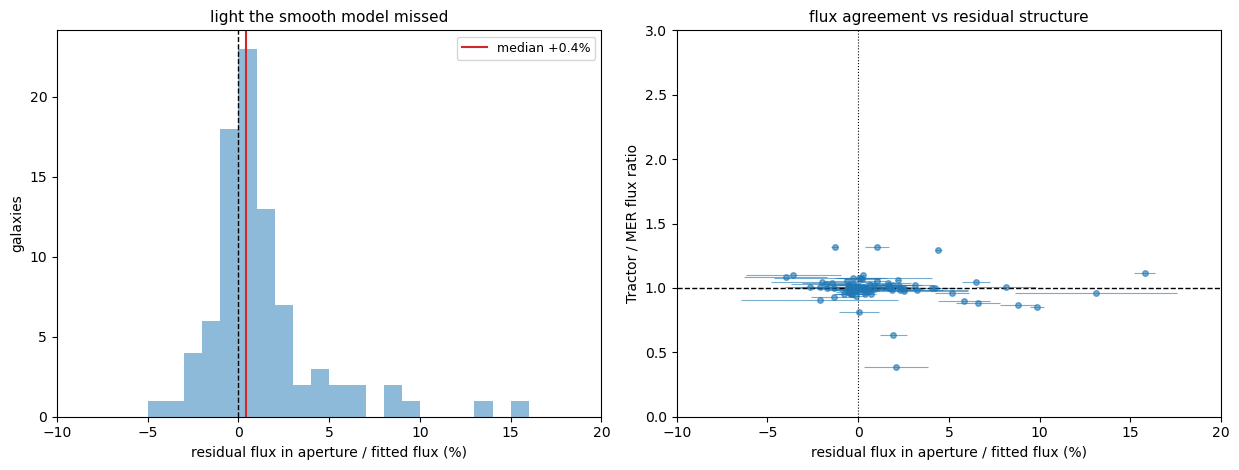

In [18]:
pixscale = cutouts['VIS'].pixel_scale_arcsec
magzero = float(cutouts['VIS'].header['MAGZERO'])
counts_to_ujy = 3.631 / 10 ** (0.4 * (magzero - 22.5))
residual = full_data - full_model

def _re_arcsec(src):
    try:
        return float(src.getShape().re)
    except Exception:
        return np.nan   # PointSource / composite: fall back below

_coords = SkyCoord(np.asarray(mer_cat['ra'], float),
                   np.asarray(mer_cat['dec'], float), unit='deg')
_, _nnsep, _ = _coords.match_to_catalog_sky(_coords, nthneighbor=2)
nn_arcsec = _nnsep.arcsec

H, W = full_data.shape
f_res = np.full(len(sources), np.nan)
f_res_err = np.full(len(sources), np.nan)
for i, src in enumerate(sources):
    if is_star[i] or not (fit_quality[i] and measured[i]) or contam[i]:
        continue
    re_as = _re_arcsec(src)
    r_as = float(np.clip(3.0 * (re_as if np.isfinite(re_as) else 0.3),
                         0.8, 3.0))
    if nn_arcsec[i] < r_as + 0.5:
        continue                    # a neighbor would enter the sum
    px, py = tim_vis.getWcs().positionToPixel(src.getPosition())
    r_pix = r_as / pixscale
    if not (r_pix <= px < W - r_pix and r_pix <= py < H - r_pix):
        continue
    x0, x1 = int(px - r_pix) - 1, int(px + r_pix) + 2
    y0, y1 = int(py - r_pix) - 1, int(py + r_pix) + 2
    dy = np.arange(y0, y1)[:, None] - py
    dx = np.arange(x0, x1)[None, :] - px
    good = ((dx ** 2 + dy ** 2) <= r_pix ** 2) \
        & (full_invvar[y0:y1, x0:x1] > 0)
    if good.sum() < 10:
        continue
    _sum = float(np.sum(residual[y0:y1, x0:x1][good]))
    _sig = float(np.sqrt(np.sum(1.0 / full_invvar[y0:y1, x0:x1][good])))
    f_res[i] = _sum * counts_to_ujy / tractor_vis_ujy[i]
    f_res_err[i] = _sig * counts_to_ujy / tractor_vis_ujy[i]

# Bright enough that the fraction measures structure, not sky noise.
sel_f = np.isfinite(f_res) & (tractor_vis_ujy > 2.0)
n_sig = np.abs(f_res[sel_f] / f_res_err[sel_f])
print(f"{int(sel_f.sum())} isolated galaxies above 2 uJy; median aperture "
      f"noise on the fraction: {100 * np.nanmedian(f_res_err[sel_f]):.1f}%")
print(f"missed-light fraction: median {100 * np.median(f_res[sel_f]):+.1f}%, "
      f"68% within {100 * np.percentile(np.abs(f_res[sel_f]), 68):.1f}%, "
      f"max |f_res| {100 * np.max(np.abs(f_res[sel_f])):.1f}%")
print(f"structure detected (|f_res| > 3 sigma): "
      f"{int((n_sig > 3).sum())}/{int(sel_f.sum())}")

# Does the MER agreement degrade with residual structure?
lo = sel_f & (np.abs(f_res) <= np.median(np.abs(f_res[sel_f])))
hi = sel_f & (np.abs(f_res) > np.median(np.abs(f_res[sel_f])))
print(f"median Tractor/MER: smooth half {np.median(ratio[lo]):.3f}, "
      f"structured half {np.median(ratio[hi]):.3f}")

fig, (axh, axs) = plt.subplots(1, 2, figsize=(12.5, 4.8))
axh.hist(100 * f_res[sel_f], bins=np.linspace(-10, 20, 31),
         histtype='stepfilled', alpha=0.5, color='C0')
axh.axvline(0, color='k', ls='--', lw=1)
axh.axvline(100 * np.median(f_res[sel_f]), color='C3', lw=1.5,
            label=f"median {100 * np.median(f_res[sel_f]):+.1f}%")
axh.set_xlabel('residual flux in aperture / fitted flux (%)')
axh.set_ylabel('galaxies')
axh.set_title('light the smooth model missed', fontsize=11)
axh.set_xlim(-10, 20)
axh.legend(fontsize=9)

axs.errorbar(100 * f_res[sel_f], ratio[sel_f],
             xerr=100 * f_res_err[sel_f], fmt='o', ms=4, alpha=0.6, lw=0.8)
axs.axhline(1, color='k', ls='--', lw=1)
axs.axvline(0, color='k', ls=':', lw=0.8)
axs.set_xlabel('residual flux in aperture / fitted flux (%)')
axs.set_ylabel('Tractor / MER flux ratio')
axs.set_title('flux agreement vs residual structure', fontsize=11)
# The one catastrophic case (~29% missed light, 6x MER discrepancy) is
# left off the axes; it stays in the printed statistics above.
axs.set_xlim(-10, 20)
axs.set_ylim(0, 3)
plt.tight_layout()
plt.show()


*Structure costs almost no total flux. The missed-light fraction is
centered at +0.4 percent with 68 percent of galaxies within 2 percent
-- the same few-percent level as the injection-recovery floor of
notebook 03 -- with a small positive tail: unmodeled features are
slightly more often missed light than over-subtracted light. A sixth
of the bright sample has residual structure detected above 3 sigma of
the aperture noise, yet the MER agreement is identical for the smooth
and structured halves (1.001 vs 1.003): the fitted total is
insensitive to what the profile cannot draw. The metric also flags the
rare catastrophic case (here one source at ~29 percent missed light
and a 6x MER discrepancy, beyond the plotted axes; a deblend/model failure of the kind
section 12 dissects) -- a useful per-source quality indicator that
needs no external catalog.*


## 12. Origins of the off-1:1 VIS outliers

Four effects move a Tractor flux away from MER's value: (a) profile
differences: no smooth profile represents real galaxy structure, and
the two pipelines use different models; (b) deblending: the joint
fit and SE++ split blends differently; (c) classification: the
reference flux switches between ``flux_vis_psf`` and
``flux_vis_sersic`` with the star/galaxy call; (d) bright stars:
masked, unmeasured, and excluded from the comparison.

The printout below diagnoses each shown case: MER's fitted profile
against the tree's, MER's three fluxes (PSF / Sersic / detection-stage
total), and the nearest neighbor. A "total flux" from a fitted profile
is partly extrapolation below the noise, so two adequate fits with
different (n, r_e) can disagree by tens of percent while both leave
clean residuals.

Showing 2 representative outliers:
  row  557  is_star=False  MER    6.35 uJy  Tractor   15.06 uJy  ratio=2.37  class=SersicGalaxy
        MER profile n=1.2 re=1.72"  vs  tree re=4.53" n=2.5
        MER psf/sersic/detection = 0.1/6.4/7.7 uJy; nearest neighbor 1.9" (0.1 uJy)
  row   60  is_star=False  MER   10.70 uJy  Tractor    6.79 uJy  ratio=0.63  class=SimpleGalaxy
        MER profile n=5.5 re=0.73"  vs  tree re=0.30"
        MER psf/sersic/detection = 2.9/10.7/9.7 uJy; nearest neighbor 2.6" (0.2 uJy)


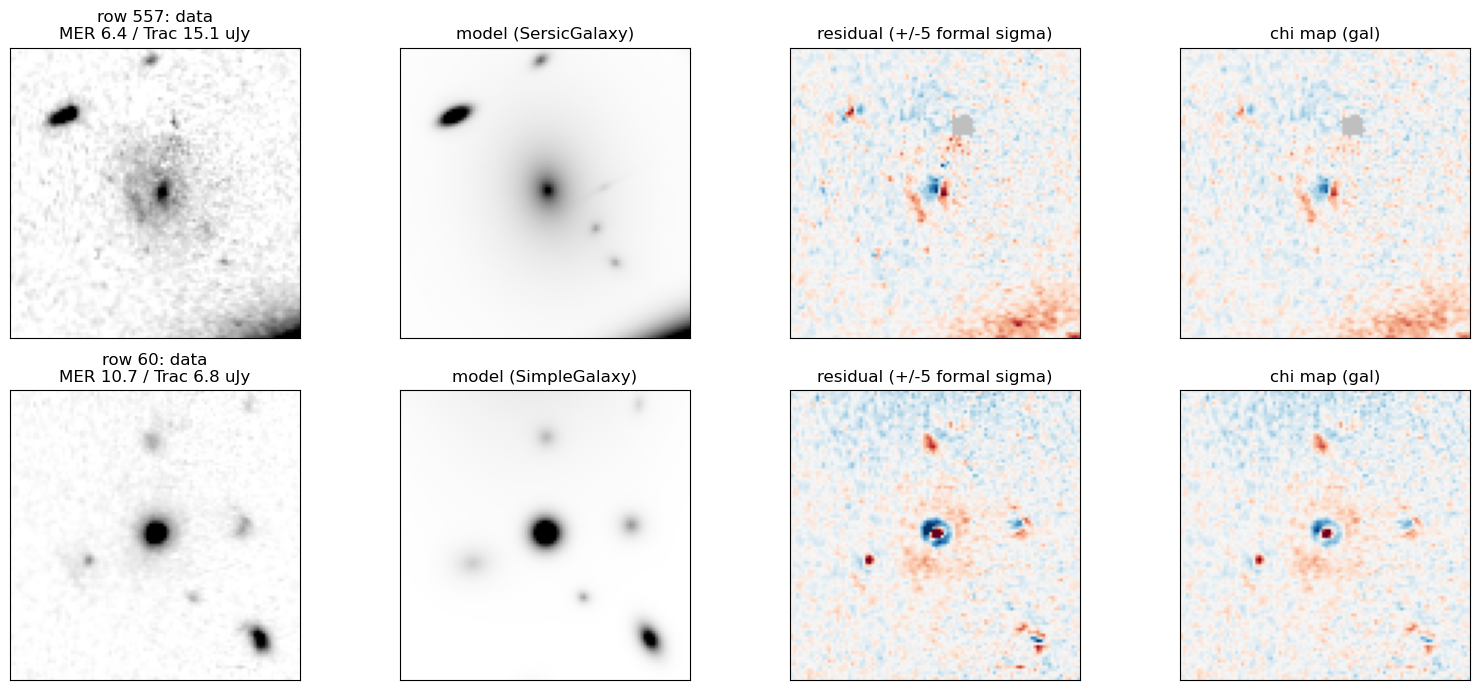

In [19]:
# The two largest galaxy discrepancies among the measured, unflagged
# fits. The bright stars are masked and unmeasured, so they cannot
# appear as outliers.
ref = np.where(is_star, ref_star, ref_gal)
ratio = np.where(ref > 0, tractor_vis_ujy / np.where(ref > 0, ref, np.nan), np.nan)
log_ratio = np.full(ratio.shape, np.nan)
_pos = np.isfinite(ratio) & (ratio > 0)
log_ratio[_pos] = np.log10(ratio[_pos])

# Picks must lie clear of the cutout boundary: a clipped boundary
# profile carries the `edge` flag (section 13) and is an artifact of the
# cutout, not a photometric outlier. The margin is half the display window.
_px, _py = cutouts['VIS'].wcs.world_to_pixel_values(
    np.asarray(mer_cat['ra'], float), np.asarray(mer_cat['dec'], float))
_H, _W = cutouts['VIS'].shape
_interior = ((_px > 50) & (_px < _W - 50) & (_py > 50) & (_py < _H - 50))
_gal = (fit_quality & measured & ~is_star & np.isfinite(log_ratio)
        & _interior & (ref > 5.0) & (tractor_vis_ujy > 5.0))
gal_idx = np.flatnonzero(_gal)
outlier_idx = np.array(gal_idx[np.argsort(-np.abs(log_ratio[gal_idx]))][:2])

_c12 = SkyCoord(np.asarray(mer_cat['ra'], float),
                np.asarray(mer_cat['dec'], float), unit='deg')
print(f"Showing {len(outlier_idx)} representative outliers:")
for i in outlier_idx:
    print(f"  row {i:4d}  is_star={bool(is_star[i])}  "
          f"MER {ref[i]:7.2f} uJy  Tractor {tractor_vis_ujy[i]:7.2f} uJy  "
          f"ratio={ratio[i]:.2f}  class={type(sources[i]).__name__}")
    # Diagnosis: which mechanism (a)-(d) moved this source off the 1:1.
    _n_mer = float(np.ma.filled(mer_cat['sersic_sersic_vis_index'][i], np.nan))
    _re_mer = float(np.ma.filled(mer_cat['sersic_sersic_vis_radius'][i], np.nan))
    try:
        _re_fit = float(sources[i].getShape().re)
        _n_fit = (float(sources[i].sersicindex.getValue())
                  if hasattr(sources[i], 'sersicindex') else None)
        _fit_txt = (f"re={_re_fit:.2f}\" n={_n_fit:.1f}" if _n_fit is not None
                    else f"re={_re_fit:.2f}\"")
    except Exception:
        _fit_txt = "point-like"
    _sep = _c12[i].separation(_c12).arcsec
    _sep[i] = np.inf
    _j = int(np.argmin(_sep))
    print(f"        MER profile n={_n_mer:.1f} re={_re_mer:.2f}\"  vs  "
          f"tree {_fit_txt}")
    print(f"        MER psf/sersic/detection = "
          f"{float(np.ma.filled(mer_cat['flux_vis_psf'][i], np.nan)):.1f}/"
          f"{float(np.ma.filled(mer_cat['flux_vis_sersic'][i], np.nan)):.1f}/"
          f"{float(np.ma.filled(mer_cat['flux_detection_total'][i], np.nan)):.1f} uJy; "
          f"nearest neighbor {_sep[_j]:.1f}\" ({ref[_j]:.1f} uJy)")

# Render the per-source 4-panel cutouts. The window is wide enough (~10 arcsec)
# to show a bright star's diffraction spikes; full_data/model/invvar
# carry over from section 11.
CUT_PIX = 100  # +/- 50 pixels = ~10 arcsec at VIS scale

fig, axes = plt.subplots(len(outlier_idx), 4,
                          figsize=(16, 3.5 * len(outlier_idx)))
if len(outlier_idx) == 1:
    axes = axes[np.newaxis, :]
for row, i in enumerate(outlier_idx):
    px, py = tim_vis.getWcs().positionToPixel(sources[i].getPosition())
    px, py = int(round(px)), int(round(py))
    sl_y = slice(max(0, py - CUT_PIX // 2),
                 min(full_data.shape[0], py + CUT_PIX // 2))
    sl_x = slice(max(0, px - CUT_PIX // 2),
                 min(full_data.shape[1], px + CUT_PIX // 2))
    d = full_data[sl_y, sl_x]
    m = full_model[sl_y, sl_x]
    iv = full_invvar[sl_y, sl_x]
    vmax = float(np.nanpercentile(d, 99.5))
    axes[row, 0].imshow(d, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    axes[row, 0].set_title(
        f"row {i}: data\nMER {ref[i]:.1f} / Trac {tractor_vis_ujy[i]:.1f} uJy")
    axes[row, 1].imshow(m, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    axes[row, 1].set_title(f"model ({type(sources[i]).__name__})")
    ep.viz.show_residual(d, m, invvar=iv, ax=axes[row, 2],
                         title='residual (+/-5 formal sigma)')
    ep.viz.show_chi_map(d, m, iv, ax=axes[row, 3],
                        title=f"chi map ({'star' if is_star[i] else 'gal'})")
    for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

*On this field both outliers are case (a), and specifically the
wings. Row 557 is a clumpy low-surface-brightness disk: both pipelines
fit large disk-like profiles, but with different (n, r_e), and the two
totals -- each partly wing extrapolation -- differ by 2.4x. Row 60 is
compact: MER's near-railed n = 5.5 puts a large fraction of its total
below the noise, while the tree kept the compact bridge tier; the
detection-stage total sits between the two. Neither is a blend -- the
nearest neighbors are ten times fainter. Chi-squared on the pixels
cannot arbitrate wing extrapolation, which is why the catalog carries
the model class per source and why the section-11 residual fraction is
the right flag for cases worth inspecting.*


## 13. Source quality flags and per-pixel masks

**Per-source flags.** ``ep.flag_sources`` marks bright stars
(``bright_star``), their neighbors within the halo radius
(``near_bright_star``), cores on bad pixels (``masked``), and sources
within 1 arcsec of the cutout boundary (``edge``; kept in the model
so their light cannot contaminate neighbors, but their own clipped
flux needs a larger cutout). ``reliable`` is the conjunction.

**Per-pixel masks.** ``with_flag=True`` retrieves the MER FLG plane;
``build_tractor_image`` zeroes the inverse variance of flagged pixels.
Only the coadd-fatal bits are masked (``MER_VIS_BAD_BITS``: INVALID,
SAT, NO_DATA) plus the STARSIGNAL bit when ``MASK_BRIGHT_STARS`` is
on; the remaining FLG bits record per-frame history (COSMIC alone
covers ~15% of this field) and masking them would discard usable sky.


In [20]:
quality = ep.flag_sources(
    np.asarray(mer_cat['ra']), np.asarray(mer_cat['dec']),
    tractor_vis_ujy, ep.probable_bright_stars(mer_cat),
    wcs=cutouts['VIS'].wcs, flag_plane=cutouts['VIS'].flag,
    bright_star_ujy=80.0, neighbor_radius_arcsec=6.0)

n = len(quality)
print(f"bright stars (flux > 80 uJy):  {int(quality['bright_star'].sum())}")
print(f"within 6 arcsec of one:        {int(quality['near_bright_star'].sum())}")
print(f"core on a coadd-bad pixel:     {int(quality['masked'].sum())}")
print(f"clipped by the cutout edge:    {int(quality['edge'].sum())}")
print(f"reliable:                      {int(quality['reliable'].sum())} / {n}")

# The biased bright star from section 9 is flagged unreliable.
_bs = np.flatnonzero(np.asarray(quality['bright_star']))
if len(_bs):
    i = _bs[np.argmax(tractor_vis_ujy[_bs])]
    print(f"\nbrightest flagged star: row {i}, VIS = {tractor_vis_ujy[i]:.0f} uJy, "
          f"reliable = {bool(quality['reliable'][i])}")

# Composition of the FLG plane: the coadd-fatal cut drops few pixels
# compared with the history and object-footprint bits it leaves in.
flag_plane = cutouts['VIS'].flag
if flag_plane is not None:
    npix = flag_plane.size
    f_bad = 100 * ((flag_plane & ep.MER_VIS_BAD_BITS) != 0).sum() / npix
    f_obj = 100 * ((flag_plane & (1 << 24)) != 0).sum() / npix
    f_cos = 100 * (((flag_plane >> 4) & 1) != 0).sum() / npix
    print(f"\nFLG plane: {f_bad:.3f}% coadd-fatal (masked), "
          f"{f_obj:.1f}% OBJECTS footprints, {f_cos:.1f}% COSMIC history (kept)")

bright stars (flux > 80 uJy):  11
within 6 arcsec of one:        52
core on a coadd-bad pixel:     10
clipped by the cutout edge:    21
reliable:                      1033 / 1119

brightest flagged star: row 0, VIS = 396 uJy, reliable = False

FLG plane: 0.061% coadd-fatal (masked), 11.5% OBJECTS footprints, 14.7% COSMIC history (kept)


## 14. Empirical calibration of the flux errors

The formal errors assume independent pixels (``invvar = 1/rms^2``),
but the MER mosaics are resampled coadds: the chi width of ~0.56 in
section 9 is the signature of correlated pixel noise. A PSF-weighted
flux sums many correlated pixels, so per-pixel statistics cannot
establish whether the flux errors are correct.

A test that can is to fit point-source fluxes at a few hundred
source-free positions with the step-1 machinery, the PSF-scale
analogue of the empty-aperture technique. The recovered flux/error
ratios should scatter as N(0,1); the measured width is the
error-inflation factor. ``run_forced_photometry`` applies this
automatically (``calibrate_errors=True``, the default); here it is
done explicitly.


VIS: 200 empty positions, flux/err scatter (chi_mad) = 0.807
     formal err median = 0.0073 uJy, empirical sigma = 0.0059 uJy
     adopted inflation = x1.000 (clamped at >= 1; errors are never deflated)


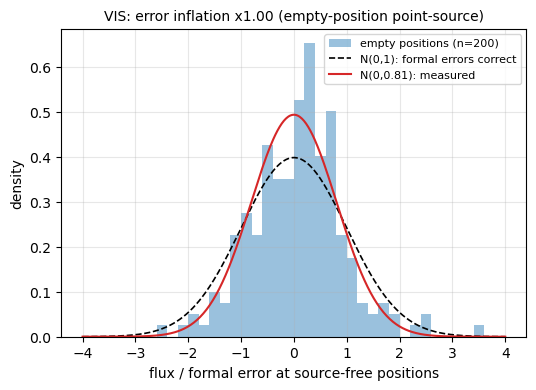

In [21]:
calib_vis = ep.measure_error_inflation(
    cutouts['VIS'], psf_stamp_vis, mer_cat, band='VIS',
    n_positions=200, invvar=tim_vis.getInvvar(), rng=0)
print(f"VIS: {calib_vis['n_positions']} empty positions, "
      f"flux/err scatter (chi_mad) = {calib_vis['chi_mad']:.3f}")
print(f"     formal err median = {calib_vis['formal_err_med_ujy']:.4f} uJy, "
      f"empirical sigma = {calib_vis['empirical_sigma_ujy']:.4f} uJy")
print(f"     adopted inflation = x{calib_vis['inflation']:.3f} "
      f"(clamped at >= 1; errors are never deflated)")

ep.viz.show_error_calibration(calib_vis)
plt.show()

## 15. NISP PSFs

The GRID-PSF extraction of section 5 is repeated for Y, J, and H.
The gallery below shows the field-average stamp in each band on a
common logarithmic stretch, annotated with the median FWHM and the
number of contributing stamps. All MER products share the 0.1 arcsec
mosaic grid, so the panels span the same angular extent; the NISP PSFs
are roughly 2.5 times broader than VIS.


In [22]:
psf_data_nisp = {}
psf_stamp_nisp = {}
for band in ('Y', 'J', 'H'):
    psf_data_nisp[band] = ep.extract_grid_psf(
        band, TARGET_RA, TARGET_DEC, radius_arcsec=150.0,
        data_dir=DATA_DIR / 'psf')
    psf_stamp_nisp[band], fwhm = ep.psf_summary(psf_data_nisp[band])
    print(f"  NISP-{band} GRID-PSF: {len(psf_data_nisp[band]['stamps'])} stamps, "
          f"median FWHM = {fwhm:.3f} arcsec")


  NISP-Y GRID-PSF: 486 stamps, median FWHM = 0.479 arcsec
  NISP-J GRID-PSF: 486 stamps, median FWHM = 0.503 arcsec
  NISP-H GRID-PSF: 486 stamps, median FWHM = 0.544 arcsec


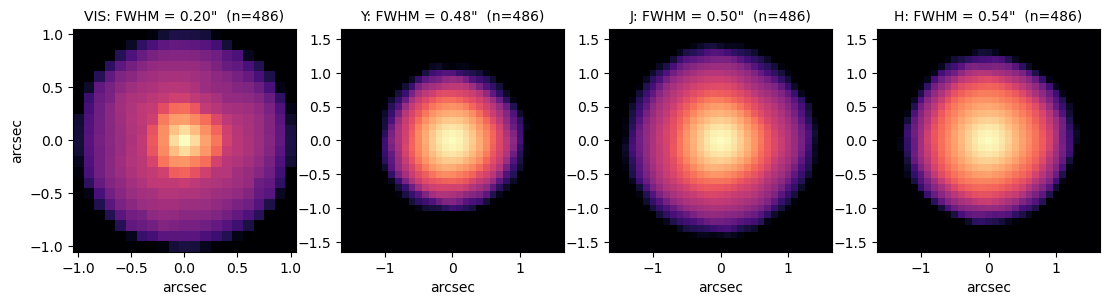

In [23]:
# The four Euclid PSFs side by side: log stretch, native pixel scales.
ep.viz.show_psf_stamps(
    {'VIS': psf_data_vis, **psf_data_nisp},
    pixel_scale_arcsec={b: cutouts[b].pixel_scale_arcsec
                        for b in ('VIS', 'Y', 'J', 'H')})
plt.tight_layout(); plt.show()


*The measured field-average FWHM is ~0.2 arcsec in VIS and ~0.5 arcsec
in the NISP bands, so each NISP resolution element covers roughly six
VIS resolution elements. This is why VIS serves as the prior band:
positions and shapes are constrained there and only fluxes are fitted
in Y/J/H.*


## 16. NISP forced photometry

The bright-star pixel veto from section 5 carries over here: all MER
mosaics, NISP included, share the common 0.1 arcsec VIS grid, so the
VIS STARSIGNAL mask aligns pixel-for-pixel with the Y/J/H cutouts and
the star halos and spikes are excluded from those flux fits too.


In [24]:
t0 = time.time()
nisp_results = ep.fit_nisp_forced(
    sources,
    {b: cutouts[b]        for b in ('Y', 'J', 'H')},
    {b: psf_stamp_nisp[b] for b in ('Y', 'J', 'H')},
    # Same 0.1 arcsec grid as VIS, so the STARSIGNAL veto carries over.
    pixel_mask=star_mask,
    n_workers=N_WORKERS,
)
# fit_nisp_forced returns {band: {"flux_ujy": ..., "flux_err_ujy": ...}}.
# Split into plain per-band arrays the rest of the notebook consumes.
nisp_flux_ujy = {b: nisp_results[b]['flux_ujy']     for b in ('Y', 'J', 'H')}
nisp_err_ujy  = {b: nisp_results[b]['flux_err_ujy'] for b in ('Y', 'J', 'H')}
print(f"NISP forced phot done in {time.time()-t0:.1f} s")
for band in ('Y', 'J', 'H'):
    f = nisp_flux_ujy[band]
    print(f"  {band}: flux range {np.nanmin(f):.2f} - {np.nanmax(f):.0f} microJansky")

NISP forced phot done in 39.6 s
  Y: flux range -37.69 - 1451 microJansky
  J: flux range -60.56 - 1647 microJansky
  H: flux range -55.51 - 1961 microJansky


### NISP versus MER

The same comparison as section 10, per NISP band, against MER's
``flux_<band>_templfit`` photometry (template fitting on the NISP
images at VIS-defined positions). Top row: the flux-flux relation
against the 1:1 line. Bottom row: the magnitude difference against
magnitude, with the median and NMAD in equal-population bins. Sources
detected at S/N > 5 in the Tractor fit are shown.


Y: n=574, median(Tractor/MER_templfit) = 1.004, NMAD(dmag) = 0.119 mag
J: n=694, median(Tractor/MER_templfit) = 1.003, NMAD(dmag) = 0.119 mag
H: n=715, median(Tractor/MER_templfit) = 0.999, NMAD(dmag) = 0.118 mag


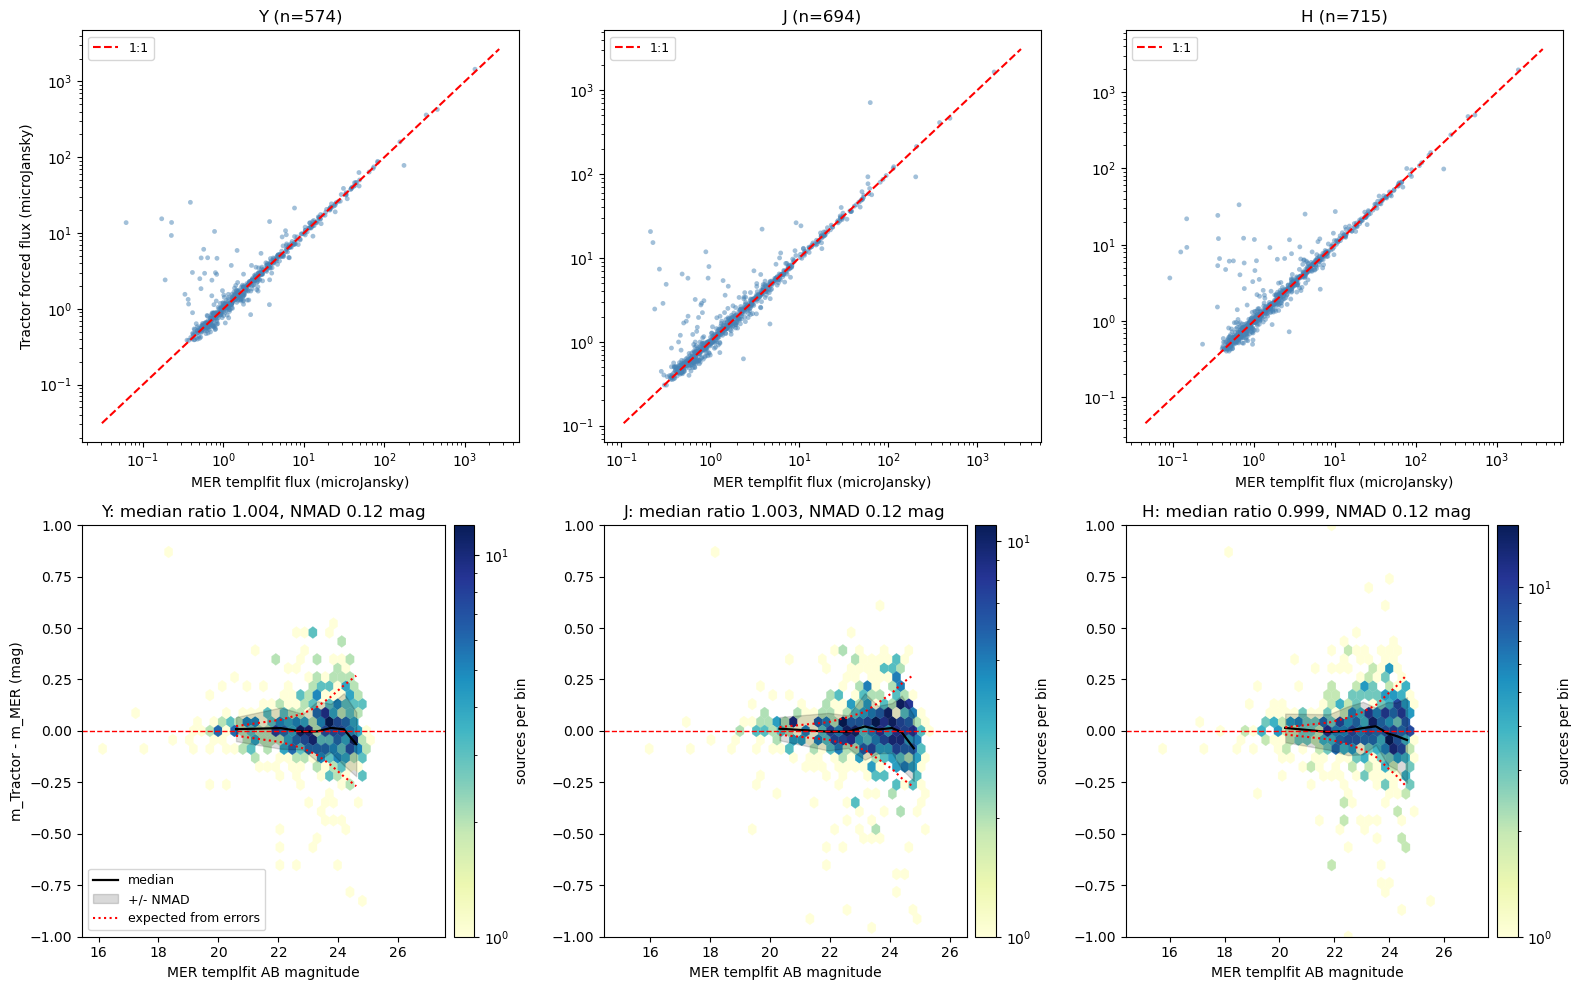

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for col, band in enumerate(('Y', 'J', 'H')):
    ours = np.asarray(nisp_flux_ujy[band], float)
    errs = np.asarray(nisp_err_ujy[band], float)
    ref_n = np.ma.filled(
        np.ma.asarray(mer_cat[f'flux_{band.lower()}_templfit'], float), np.nan)
    with np.errstate(invalid='ignore', divide='ignore'):
        snr = ours / errs
    ok = (fit_quality & np.isfinite(ours) & np.isfinite(ref_n)
          & (ref_n > 0) & (ours > 0) & (snr > 5))

    # Top: flux-flux relation against the 1:1 line.
    axf = axes[0, col]
    axf.scatter(ref_n[ok], ours[ok], s=12, c='steelblue', alpha=0.5,
                edgecolors='none')
    lims = (float(np.nanmin(ref_n[ok])) * 0.5,
            float(np.nanmax(ref_n[ok])) * 2.0)
    axf.plot(lims, lims, 'r--', lw=1.5, label='1:1')
    axf.set_xscale('log'); axf.set_yscale('log')
    axf.set_xlabel('MER templfit flux (microJansky)')
    axf.set_title(f'{band} (n={int(ok.sum())})')
    axf.legend(fontsize=9)

    # Bottom: magnitude difference vs magnitude through the same helper
    # as the VIS comparison in section 10.
    err_n = np.ma.filled(np.ma.asarray(
        mer_cat[f'fluxerr_{band.lower()}_templfit'], float), np.nan)
    med = float(np.median(ours[ok] / ref_n[ok]))
    nmad = float(mad_std(-2.5 * np.log10(ours[ok] / ref_n[ok])))
    ep.viz.show_dmag_vs_mag(
        ref_n, ours, err_ujy=errs, ref_err_ujy=err_n, sel=ok,
        ax=axes[1, col], gridsize=40, max_bins=12,
        xlabel='MER templfit AB magnitude',
        ylabel='m_Tractor - m_MER (mag)' if col == 0 else '',
        title=f'{band}: median ratio {med:.3f}, NMAD {nmad:.2f} mag')
    print(f"{band}: n={int(ok.sum())}, median(Tractor/MER_templfit) = "
          f"{med:.3f}, NMAD(dmag) = {nmad:.3f} mag")
axes[0, 0].set_ylabel('Tractor forced flux (microJansky)')
axes[1, 0].legend(fontsize=9, loc='lower left')
plt.tight_layout(); plt.show()


## 17. unWISE W1/W2 cutouts

unWISE stacks the WISE and NEOWISE exposures into full-depth coadds at
2.75 arcsec per pixel (Lang 2014; Meisner et al. 2017). The PSF FWHM is
~6.9 arcsec, so several Euclid sources fall within one WISE resolution
element. Tractor's joint solve handles this: each Euclid source
contributes an independent flux parameter, and the simultaneous fit
performs the deblending.

A slightly larger box is fetched so that the
PSF wings of sources near the edge do not extend beyond the fit
footprint.


In [26]:
if TARGET_BANDS["wise"]:
    wise_box = max(180.0, float(CUTOUT_SIZE_ARCSEC) + 120.0)
    wise = ep.fetch_unwise_cutouts(
        TARGET_RA, TARGET_DEC, wise_box,
        data_dir=DATA_DIR / 'wise')
    psf_w1 = ep.get_wise_psf(1, wise['coadd_id'])
    psf_w2 = ep.get_wise_psf(2, wise['coadd_id'])
    print(f"unWISE box: {wise_box:.0f} arcsec, coadd_id={wise['coadd_id']}")
    print(f"W1 data shape: {wise['W1']['data'].shape}")
    # The 31-bit unWISE bitmask (Meisner 2018) is retrieved per tile from
    # the coadd archive; fit_wise_forced drops the diffraction-spike,
    # halo, and ghost pixels (ep.wise.UNWISE_BAD_BITS) before solving.
    _msk = wise['W1'].get('mask')
    if _msk is not None:
        from euclid_phot.wise import UNWISE_BAD_BITS
        _nbad = int(((_msk & UNWISE_BAD_BITS) != 0).sum())
        print(f"unWISE bitmask: {_nbad} spike/halo/ghost pixel(s) masked in the box")
    else:
        print("unWISE bitmask: not available for this tile (masking skipped)")
else:
    wise = None
    print("TARGET_BANDS['wise'] is empty; skipping unWISE.")


unWISE box: 320 arcsec, coadd_id=2709p666
W1 data shape: (116, 116)
unWISE bitmask: 0 spike/halo/ghost pixel(s) masked in the box


## 18. WISE forced photometry: frozen VIS models and a joint sky

The VIS-fitted models are carried to W1/W2 exactly as to NISP:
positions and shapes frozen, flux the only free parameter per source,
plus one sky offset per band. At the ~6.9 arcsec WISE PSF every Euclid
profile is effectively unresolved, which is why Lang et al. (2016,
section 3.2) reduce all such sources to point sources; here the models
are kept so all bands measure one light profile
(``source_models="point"`` restores the reduction).

The flux fit is linear with no positivity constraint: a faint prior
can return a negative flux when noise or a neighbor dominates. That is
the unbiased behavior for stacking, but individual values need an S/N cut.

After convergence, the chi MAD on source-sparse pixels gives the
inflation factor ``k`` that scales the reported errors: the unWISE
inverse variance excludes confusion and coadd-correlation noise
(Lang 2014).


In [27]:
if wise is not None:
    t0 = time.time()
    wise_results = ep.fit_wise_forced(
        sources, wise,
        ra=TARGET_RA, dec=TARGET_DEC,
        cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
        bands=TARGET_BANDS["wise"],
    )
    print(f"WISE forced phot done in {time.time()-t0:.1f} s")
    for band in TARGET_BANDS["wise"]:
        r = wise_results[band]
        sn = r['flux_ujy'] / np.where(r['flux_err_ujy'] > 0,
                                        r['flux_err_ujy'], np.inf)
        print(f"  {band}: sky={r['sky']:+.3f} nMgy/pix, "
              f"chi inflation={r['chi_inflation']:.2f}, "
              f"S/N>3 in {int(np.nansum(sn > 3))}/{len(sources)} sources")
else:
    wise_results = None


WISE forced phot done in 101.6 s
  W1: sky=-1.294 nMgy/pix, chi inflation=1.84, S/N>3 in 566/1119 sources
  W2: sky=-2.560 nMgy/pix, chi inflation=1.14, S/N>3 in 560/1119 sources


## 19. WISE data, model, residual, and chi

Two panels per band as before, together with the chi map. For unWISE
forced photometry the chi map is the more informative diagnostic: the
raw residual ``(data - model)`` is dominated by the sky offset and the
brightest source remnants, whereas chi expresses every pixel in units
of its own formal noise.


W1: formal sigma = 0.1753 Vega nMgy, chi std = 8.31 (k = 1.84), |chi|>3 = 29.76%, k-pool: source-sparse (|mod|<1sigma) (1100 pixels)
W2: formal sigma = 0.6261 Vega nMgy, chi std = 2.29 (k = 1.14), |chi|>3 = 7.54%, k-pool: source-sparse (|mod|<1sigma) (1958 pixels)


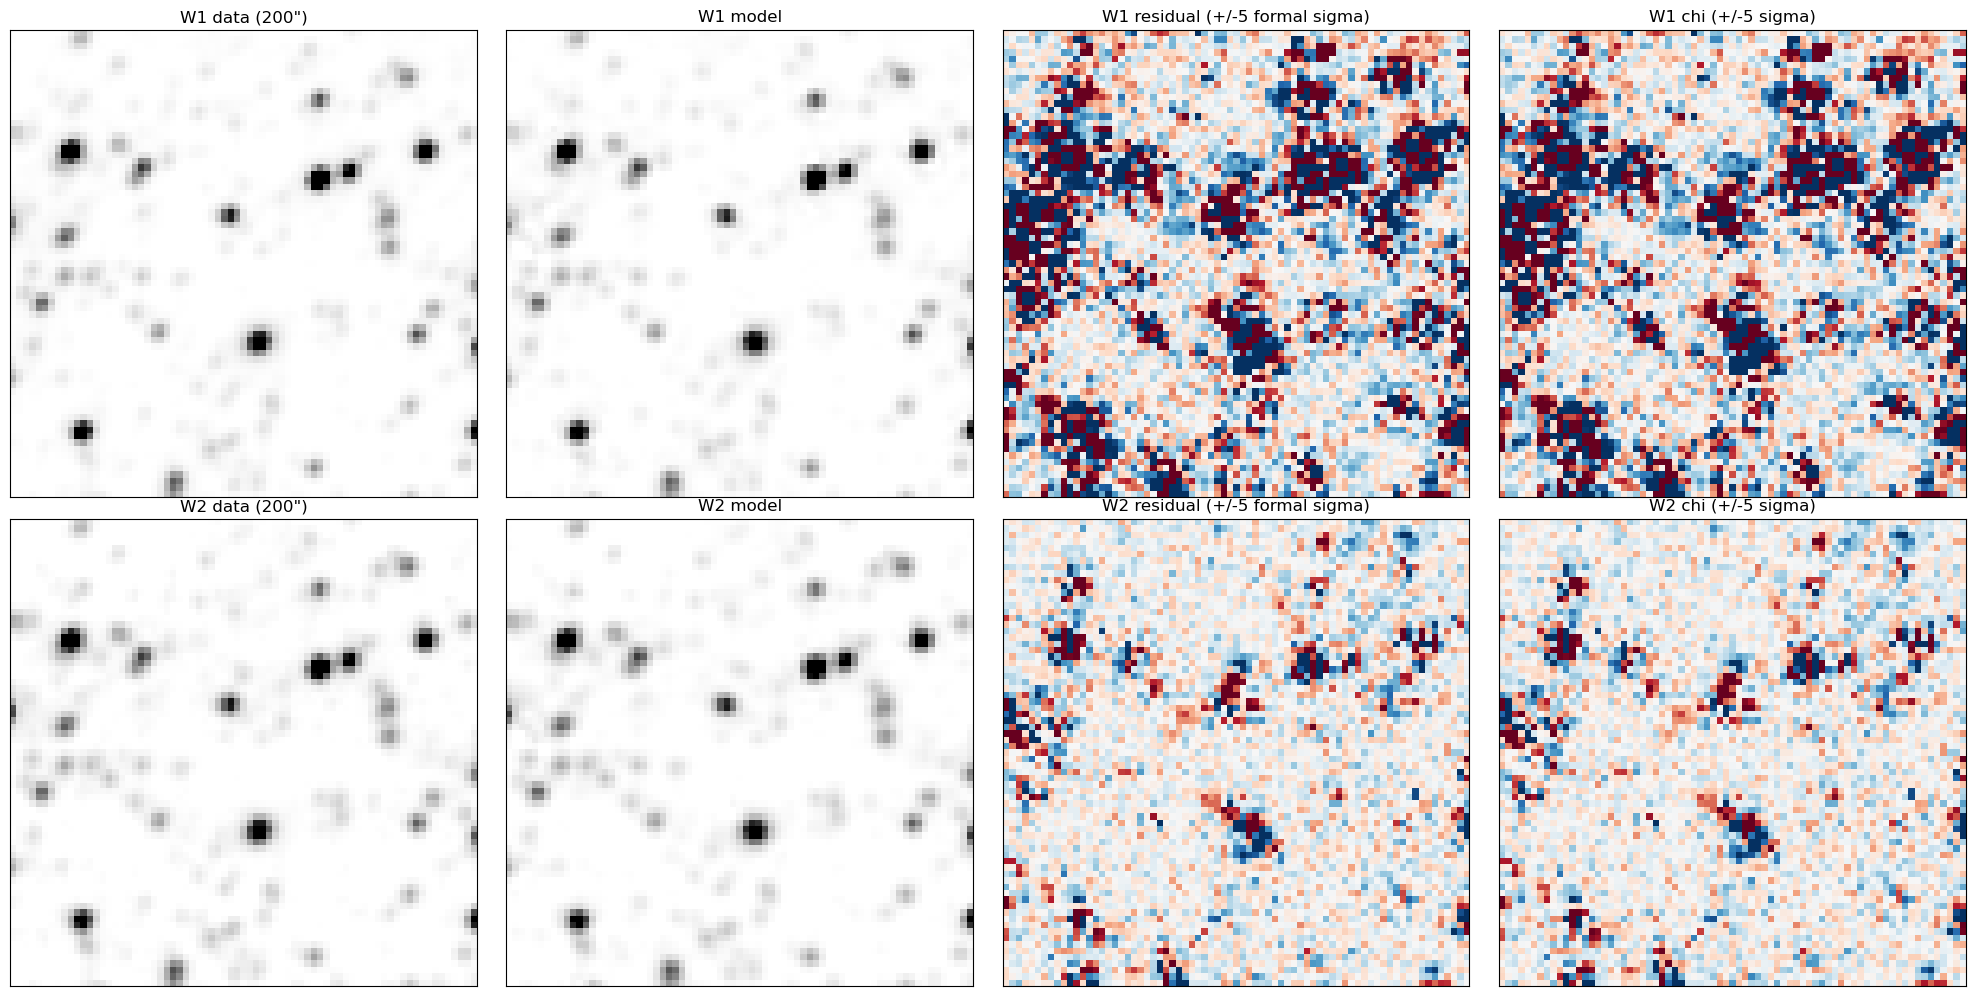

In [28]:
if wise_results is not None:
    from astropy.nddata import Cutout2D
    import astropy.units as u

    bands_to_show = TARGET_BANDS["wise"]
    fig, axes = plt.subplots(len(bands_to_show), 4,
                              figsize=(20, 5 * len(bands_to_show)))
    if len(bands_to_show) == 1:
        axes = axes[np.newaxis, :]
    for row_idx, band in enumerate(bands_to_show):
        r = wise_results[band]
        # Show W1/W2 at the CUTOUT_SIZE_ARCSEC box used for VIS/NISP; the fit
        # uses the full padded region.
        wcs_w = r['wcs']
        cx, cy = wcs_w.world_to_pixel_values(TARGET_RA, TARGET_DEC)
        pos = (float(cx), float(cy))
        box = CUTOUT_SIZE_ARCSEC * u.arcsec
        data = Cutout2D(r['data'], pos, box, wcs=wcs_w,
                        mode='partial', fill_value=0.0).data
        model = Cutout2D(r['model'], pos, box, wcs=wcs_w,
                         mode='partial', fill_value=0.0).data
        invvar = Cutout2D(r['invvar'], pos, box, wcs=wcs_w,
                          mode='partial', fill_value=0.0).data
        vmax = float(np.nanpercentile(data, 99.5))
        axes[row_idx, 0].imshow(data, origin='lower', cmap='gray_r',
                                vmin=0, vmax=vmax)
        axes[row_idx, 0].set_title(f'{band} data ({CUTOUT_SIZE_ARCSEC:.0f}")')
        axes[row_idx, 1].imshow(model, origin='lower', cmap='gray_r',
                                vmin=0, vmax=vmax)
        axes[row_idx, 1].set_title(f'{band} model')
        _, info_res = ep.viz.show_residual(
            data, model, invvar=invvar,
            ax=axes[row_idx, 2],
            title=f'{band} residual (+/-5 formal sigma)')
        _, info_chi = ep.viz.show_chi_map(
            data, model, invvar,
            ax=axes[row_idx, 3], title=f'{band} chi (+/-5 sigma)')
        for ax in axes[row_idx]: ax.set_xticks([]); ax.set_yticks([])
        print(f"{band}: formal sigma = {info_res['formal_sigma']:.4f} Vega nMgy, "
              f"chi std = {info_chi['chi_std']:.2f} (k = {r['chi_inflation']:.2f}), "
              f"|chi|>3 = {info_chi['pct_chi_gt_3']:.2f}%, "
              f"k-pool: {r['chi_pool_kind']} ({r['n_chi_pool']} pixels)")
    plt.tight_layout(); plt.show()

## 20. Cross-check against the Schlafly et al. (2019) unWISE catalog

The reference is the unWISE catalog of Schlafly et al. (2019; IRSA
table ``unwise_2019``): it was built with ``crowdsource``, a
simultaneous PSF-fitting code of the same class as Tractor, so the
comparison isolates fitting choices. It used earlier-epoch coadds than
the NEO7 fit here, so depth and epoch differences also enter.

**Isolation criterion.** Following the intent of Lang et al. (2016,
section 3.3), a source is isolated if no MER neighbor with more than
1/3 of its VIS flux lies within 2 unWISE FWHM (~14 arcsec). This
yields 33 isolated sources here; a strict "no neighbor within
3 FWHM" cut would yield none at this source density.


In [29]:
# Query Schlafly+19 (unwise_2019) and match to Tractor positions.
WISE_FWHM_ARCSEC = 6.94
MATCH_RADIUS_ARCSEC = 1.0          # tighter than the 1.5" default to
                                    # reduce false positives in the dense
                                    # EDFN field (Marocco+2021 Table 7
                                    # quotes CatWISE astrometric sigma ~0.2").
ISOLATION_RADIUS_ARCSEC = 2 * WISE_FWHM_ARCSEC  # Lang+2016 sec 3.3
ISOLATION_FLUX_FRACTION = 1.0 / 3.0             # "bright neighbor" = >1/3 of target

try:
    uw_cat = ep.query_unwise_2019(TARGET_RA, TARGET_DEC,
                                    CUTOUT_SIZE_ARCSEC / 2 * 1.2)
    print(f"unWISE-Schlafly: {len(uw_cat)} primary detections within "
          f"{CUTOUT_SIZE_ARCSEC/2*1.2:.0f} arcsec")
except Exception as exc:
    uw_cat = None
    print(f"unwise_2019 query failed ({exc!r}); skipping section 20.")

if uw_cat is not None and len(uw_cat) > 0:
    uw_ra  = np.asarray(uw_cat['ra'],  dtype=float)
    uw_dec = np.asarray(uw_cat['dec'], dtype=float)
    src_coord = SkyCoord(
        [float(row['ra'])  for row in mer_cat],
        [float(row['dec']) for row in mer_cat],
        unit='deg')
    uw_coord = SkyCoord(uw_ra, uw_dec, unit='deg')
    idx, sep2d, _ = src_coord.match_to_catalog_sky(uw_coord)
    matched = sep2d.arcsec < MATCH_RADIUS_ARCSEC

    # Brightness-weighted isolation: no MER neighbor within 14" whose
    # VIS flux exceeds 1/3 of the target's. We use VIS reference flux
    # because that is the WISE-band proxy that is independent of our
    # Tractor fit.
    vis_ref = np.where(is_star, ref_star, ref_gal)
    isolated = np.zeros(len(src_coord), dtype=bool)
    for i in range(len(src_coord)):
        if not (vis_ref[i] > 0):
            continue
        sep = src_coord[i].separation(src_coord).arcsec
        sep[i] = np.inf
        bright_near = (sep < ISOLATION_RADIUS_ARCSEC) & (
            vis_ref > ISOLATION_FLUX_FRACTION * vis_ref[i])
        isolated[i] = not bright_near.any()

    print(f"  matched to Tractor at {MATCH_RADIUS_ARCSEC} arcsec: "
          f"{int(matched.sum())}")
    print(f"  bright-isolated (no MER neighbor >{ISOLATION_FLUX_FRACTION:.2f} "
          f"x target VIS within {ISOLATION_RADIUS_ARCSEC:.0f}\"): "
          f"{int(isolated.sum())}")
    print(f"  matched AND bright-isolated:  {int((matched & isolated).sum())}")
else:
    matched = np.zeros(len(mer_cat), dtype=bool)
    isolated = np.zeros(len(mer_cat), dtype=bool)
    idx = np.zeros(len(mer_cat), dtype=int)


unWISE-Schlafly: 246 primary detections within 120 arcsec
  matched to Tractor at 1.0 arcsec: 132
  bright-isolated (no MER neighbor >0.33 x target VIS within 14"): 33
  matched AND bright-isolated:  25


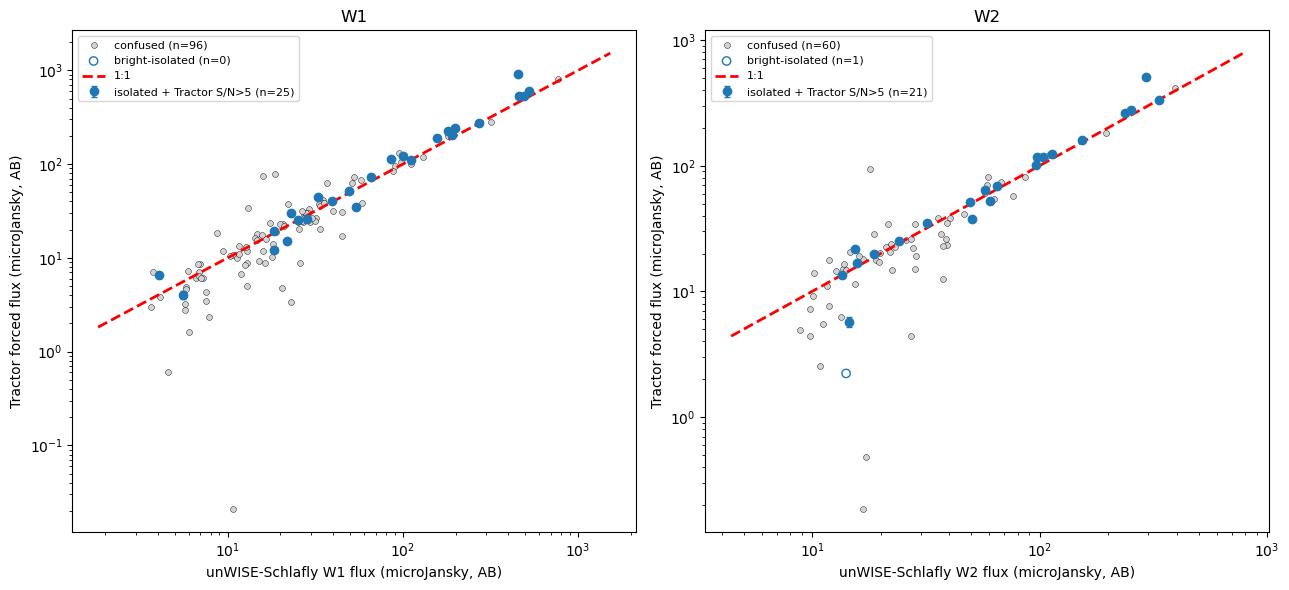

W1: median(Tractor / unWISE) all-matched (n=121) = 1.019
W1: median(Tractor / unWISE) bright-isolated S/N>5 (n=25) = 1.091  scatter = 0.11 dex
W2: median(Tractor / unWISE) all-matched (n=82) = 1.012
W2: median(Tractor / unWISE) bright-isolated S/N>5 (n=21) = 1.062  scatter = 0.12 dex

W1: median(Tractor sigma / Schlafly sigma) isolated S/N>5 (n=25) = 0.41
W2: median(Tractor sigma / Schlafly sigma) isolated S/N>5 (n=21) = 0.29


In [30]:
if uw_cat is not None and len(uw_cat) > 0 and wise_results is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    for ax, band, cw_col in zip(axes, ('W1', 'W2'), ('w1_ujy', 'w2_ujy')):
        trac = wise_results[band]['flux_ujy']
        err  = wise_results[band]['flux_err_ujy']
        uw_flux = np.asarray(uw_cat[cw_col], dtype=float)
        uw_aligned = np.full(len(sources), np.nan)
        uw_aligned[matched] = uw_flux[idx[matched]]
        sn_t = np.where(err > 0, trac / err, 0.0)

        # Three layers: (a) confused (gray, no error bars), (b) all
        # bright-isolated (open blue), (c) bright-isolated + Tractor
        # S/N > 5 (filled blue with error bars, the cleanest sample).
        m_all  = matched & np.isfinite(trac) & (trac > 0) \
                 & np.isfinite(uw_aligned) & (uw_aligned > 0)
        m_iso  = m_all & isolated
        m_hi   = m_iso & (sn_t > 5)
        m_conf = m_all & ~isolated

        ax.scatter(uw_aligned[m_conf], trac[m_conf], c='lightgray',
                   s=18, edgecolors='k', linewidths=0.3,
                   label=f'confused (n={int(m_conf.sum())})')
        ax.scatter(uw_aligned[m_iso & ~m_hi],
                   trac[m_iso & ~m_hi], facecolors='none',
                   edgecolors='C0', s=36,
                   label=f'bright-isolated (n={int((m_iso & ~m_hi).sum())})')
        if m_hi.sum() > 0:
            ax.errorbar(uw_aligned[m_hi], trac[m_hi],
                        yerr=err[m_hi], fmt='o', c='C0', ms=6,
                        capsize=2,
                        label=f'isolated + Tractor S/N>5 (n={int(m_hi.sum())})')
        all_x = np.concatenate([uw_aligned[m_all]])
        if len(all_x):
            ax.plot([all_x.min()*0.5, all_x.max()*2],
                    [all_x.min()*0.5, all_x.max()*2], 'r--', lw=2,
                    label='1:1')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(f'unWISE-Schlafly {band} flux (microJansky, AB)')
        ax.set_ylabel(f'Tractor forced flux (microJansky, AB)')
        ax.set_title(band); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    # Flux ratios: all-matched (loose) and bright-isolated high-S/N (clean).
    for band, cw_col in (('W1', 'w1_ujy'), ('W2', 'w2_ujy')):
        trac = wise_results[band]['flux_ujy']
        err  = wise_results[band]['flux_err_ujy']
        sn_t = np.where(err > 0, trac / err, 0.0)
        uw_flux = np.asarray(uw_cat[cw_col], dtype=float)
        uw_aligned = np.full(len(sources), np.nan)
        uw_aligned[matched] = uw_flux[idx[matched]]
        m_all = matched & np.isfinite(trac) & (trac > 0) \
                & np.isfinite(uw_aligned) & (uw_aligned > 0)
        m_hi  = m_all & isolated & (sn_t > 5)
        if m_all.sum():
            med_all = float(np.median(trac[m_all] / uw_aligned[m_all]))
            print(f"{band}: median(Tractor / unWISE) "
                  f"all-matched (n={int(m_all.sum())}) = {med_all:.3f}")
        if m_hi.sum():
            med_hi = float(np.median(trac[m_hi] / uw_aligned[m_hi]))
            scatter = float(np.std(np.log10(trac[m_hi] / uw_aligned[m_hi])))
            print(f"{band}: median(Tractor / unWISE) "
                  f"bright-isolated S/N>5 (n={int(m_hi.sum())}) = "
                  f"{med_hi:.3f}  scatter = {scatter:.2f} dex")

    # Error-bar calibration: Tractor 1-sigma (formal x chi-inflation) vs the
    # Schlafly+19 statistical sigma on the same bright-isolated sources. A
    # ratio near 1 means our reported uncertainty matches an independent
    # simultaneous-fit pipeline; a ratio below 1 means we under-report it.
    print()
    for band, err_col in (('W1', 'w1_err_ujy'), ('W2', 'w2_err_ujy')):
        err = wise_results[band]['flux_err_ujy']
        trac = wise_results[band]['flux_ujy']
        sn_t = np.where(err > 0, trac / err, 0.0)
        uw_err = np.asarray(uw_cat[err_col], dtype=float)
        uw_err_aligned = np.full(len(sources), np.nan)
        uw_err_aligned[matched] = uw_err[idx[matched]]
        m_hi = (matched & isolated & (sn_t > 5)
                & np.isfinite(err) & (err > 0)
                & np.isfinite(uw_err_aligned) & (uw_err_aligned > 0))
        if m_hi.sum():
            r = float(np.median(err[m_hi] / uw_err_aligned[m_hi]))
            print(f"{band}: median(Tractor sigma / Schlafly sigma) "
                  f"isolated S/N>5 (n={int(m_hi.sum())}) = {r:.2f}")
else:
    print("unWISE-Schlafly comparison skipped "
          "(no Schlafly match or WISE not run).")


*Gray: confused (a brighter MER neighbor within 14 arcsec); open
blue: bright and isolated; filled blue: bright, isolated, and Tractor
S/N > 5, the cleanest subset, whose medians are printed above. The
all-matched median falls below unity because the confused subsample
contains blends that Tractor and crowdsource decompose differently.*


## 21. The multi-band catalog

The preceding sections produced per-band flux and error arrays aligned
with the source list. ``ForcedPhotometryResult.to_table()`` joins them
into a single astropy Table: one row per object, with flux, 1-sigma
uncertainty, and AB magnitude per band, together with the model class
and quality flags. Fluxes are in microJansky on the AB system, so
``m_AB = 23.9 - 2.5 log10(flux_uJy)``.


In [31]:
from euclid_phot import ForcedPhotometryResult

# Collect the per-band fluxes and errors measured above into the same result
# object the one-call driver returns, then let it assemble the catalog.
fluxes = {'VIS': tractor_vis_ujy}
errors = {'VIS': vis_err_ujy}
for band in ('Y', 'J', 'H'):
    fluxes[band] = nisp_flux_ujy[band]
    errors[band] = nisp_err_ujy[band]
if wise_results is not None:
    for band in TARGET_BANDS['wise']:
        fluxes[band] = wise_results[band]['flux_ujy']
        errors[band] = wise_results[band]['flux_err_ujy']

# A source whose VIS fit diverged has an unreliable position, so its
# propagated fluxes are equally unreliable; mask the whole row to NaN.
for band in fluxes:
    fluxes[band] = np.where(fit_quality, fluxes[band], np.nan)
    errors[band] = np.where(fit_quality, errors[band], np.nan)

result = ForcedPhotometryResult(
    target=(TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC),
    prior=dict(PRIOR), target_bands=dict(TARGET_BANDS),
    mer_cat=mer_cat, sources=sources,
    cutouts=cutouts,
    psf_stamps={'VIS': psf_stamp_vis,
                **{b: psf_stamp_nisp[b] for b in ('Y', 'J', 'H')}},
    prior_pixel_mask=star_mask,
    fluxes_ujy=fluxes, flux_errs_ujy=errors,
    flux_quality=fit_quality,
    chosen_models=[type(s).__name__ for s in sources],
    data_dir=DATA_DIR,
)

# Empirical error calibration (section 14) for every Euclid band; the
# factors multiply the errors in place and land in the table metadata.
ep.calibrate_result_errors(result, verbose=True)

# to_table() now adds the publication columns automatically: blend /
# bright-star quality flags, per-source Galactic E(B-V) from the MER
# gal_ebv column with extinction-corrected magnitudes, and the per-band
# 5-sigma depth in the metadata.
catalog = result.to_table()
out_path = Path('forced_photometry_catalog.ecsv')
catalog.write(out_path, overwrite=True)
print(f"\nwrote {len(catalog)} sources x {len(catalog.colnames)} columns "
      f"to {out_path.resolve()}")
print(f"error inflation: {catalog.meta['error_inflation']}")
print(f"5-sigma depths (AB): {catalog.meta['depth_5sigma_ab']}")
print(f"E(B-V) source: {catalog.meta['extinction']['ebv_source']}")

# Preview the eight brightest well-fit galaxies across the bands.
cols = ['object_id', 'ra', 'dec', 'model', 'flux_quality',
        'flux_VIS_ujy', 'mag_VIS_ab', 'mag_VIS_ab_extcorr', 'mag_H_ab',
        'blended', 'reliable']
if 'mag_W1_ab' in catalog.colnames:
    cols.append('mag_W1_ab')
mask = (np.asarray(catalog['flux_quality'])
        & np.isfinite(np.asarray(catalog['mag_VIS_ab'])))
preview = catalog[mask].copy()
preview.sort('flux_VIS_ujy')
preview[cols][-8:].pprint_all()


  VIS: error inflation x1.00 (empty-position point-source, n=200)
  Y: error inflation x1.00 (empty-position point-source, n=200)


  J: error inflation x1.01 (empty-position point-source, n=200)


  H: error inflation x1.00 (empty-position point-source, n=200)

wrote 1119 sources x 52 columns to /Users/shemmati/Desktop/euclid-forced-photometry/notebooks/forced_photometry_catalog.ecsv
error inflation: {'VIS': 1.0, 'Y': 1.0, 'J': 1.0144, 'H': 1.0}
5-sigma depths (AB): {'VIS': 26.418, 'Y': 24.488, 'J': 24.54, 'H': 24.479, 'W1': 23.123, 'W2': 22.822}
E(B-V) source: MER gal_ebv (Planck R1.20, per source)
     object_id              ra                dec               model         flux_quality    flux_VIS_ujy        mag_VIS_ab     mag_VIS_ab_extcorr      mag_H_ab      blended reliable     mag_W1_ab     
                           deg                deg                                                 uJy                mag                mag                mag                                 mag        
------------------- ------------------ ----------------- -------------------- ------------ ------------------ ------------------ ------------------ ------------------ ------- -------- 

## 22. Multi-band SED of a single source


In [32]:
flux_vis_ujy = tractor_vis_ujy
have_wise = wise_results is not None
if have_wise:
    flux_w1 = wise_results['W1']['flux_ujy']
    flux_w2 = wise_results['W2']['flux_ujy']
    sn_w1 = flux_w1 / np.where(wise_results['W1']['flux_err_ujy'] > 0,
                                wise_results['W1']['flux_err_ujy'], np.inf)
else:
    flux_w1 = flux_w2 = None
    sn_w1 = np.full(len(sources), np.nan)

# Pick the galaxy whose Tractor multi-band photometry best matches MER's
# own Sersic measurements. We score each candidate by the mean absolute
# log-flux residual across VIS, Y, J, H; the smallest score is the demo
# source. Restricted to non-stars with VIS Tractor flux above 5 microJansky
# (and, when WISE is run, W1 S/N > 3) so the SED is well-defined across the
# optical-to-infrared range.
def _agreement_score(i):
    score = 0.0
    bands_used = 0
    for band, trac_arr in (('VIS', flux_vis_ujy),
                            ('Y', nisp_flux_ujy['Y']),
                            ('J', nisp_flux_ujy['J']),
                            ('H', nisp_flux_ujy['H'])):
        mer_flux = float(mer_cat[f'flux_{band.lower()}_sersic'][i])
        trac_flux = float(trac_arr[i])
        if np.isfinite(mer_flux) and mer_flux > 0 \
                and np.isfinite(trac_flux) and trac_flux > 0:
            score += abs(np.log10(trac_flux / mer_flux))
            bands_used += 1
    return score / max(1, bands_used)

candidates = [i for i, row in enumerate(mer_cat)
              if not is_star[i] and fit_quality[i]
              and np.isfinite(flux_vis_ujy[i]) and flux_vis_ujy[i] > 5.0
              and (not have_wise or (np.isfinite(sn_w1[i]) and sn_w1[i] > 3))]
candidates.sort(key=_agreement_score)   # smallest residual first
demo = candidates[0]
_w1_note = f", W1 S/N = {sn_w1[demo]:.1f}" if have_wise else ""
print(f"showing MER row {demo}: VIS={flux_vis_ujy[demo]:.1f} uJy{_w1_note}, "
      f"mean |log10(Tractor/MER)| over Euclid bands = "
      f"{_agreement_score(demo):.3f}")


showing MER row 22: VIS=33.4 uJy, W1 S/N = 230.2, mean |log10(Tractor/MER)| over Euclid bands = 0.003


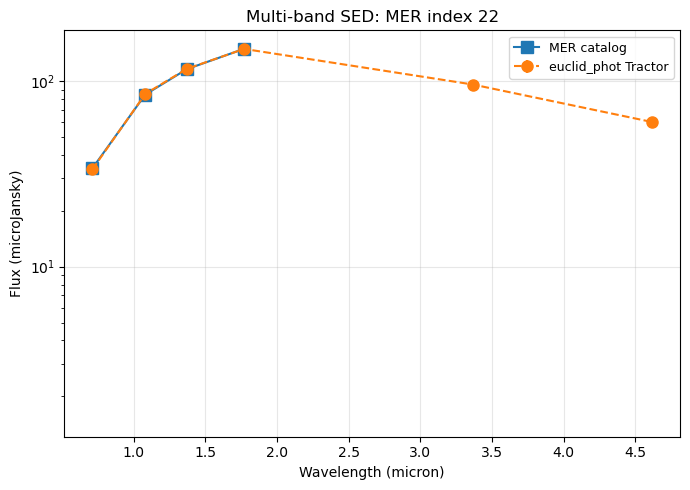

In [33]:
mer_fluxes = {
    'VIS': float(mer_cat['flux_vis_sersic'][demo]),
    'Y':   float(mer_cat['flux_y_sersic'][demo]),
    'J':   float(mer_cat['flux_j_sersic'][demo]),
    'H':   float(mer_cat['flux_h_sersic'][demo]),
}
trac_fluxes = {
    'VIS': float(flux_vis_ujy[demo]),
    'Y':   float(nisp_flux_ujy['Y'][demo]),
    'J':   float(nisp_flux_ujy['J'][demo]),
    'H':   float(nisp_flux_ujy['H'][demo]),
}
trac_errs = {
    'VIS': float(vis_err_ujy[demo]),
    'Y':   float(nisp_err_ujy['Y'][demo]),
    'J':   float(nisp_err_ujy['J'][demo]),
    'H':   float(nisp_err_ujy['H'][demo]),
}
if have_wise:
    trac_fluxes['W1'] = float(flux_w1[demo])
    trac_fluxes['W2'] = float(flux_w2[demo])
    trac_errs['W1'] = float(wise_results['W1']['flux_err_ujy'][demo])
    trac_errs['W2'] = float(wise_results['W2']['flux_err_ujy'][demo])

fig, ax = plt.subplots(figsize=(7, 5))
ep.viz.show_sed(mer_fluxes, ax=ax, label='MER catalog',
                marker='s', linestyle='-')
ep.viz.show_sed(trac_fluxes, errors_ujy=trac_errs,
                ax=ax, label='euclid_phot Tractor',
                marker='o', linestyle='--')
ax.set_title(f"Multi-band SED: MER index {demo}")
plt.tight_layout(); plt.show()


*Tractor reproduces MER's optical and near-infrared fluxes within the
uncertainties and extends the SED into the mid-infrared through the
unWISE joint-sky fit, from 0.7 to 4.6 micron in a single
forced-photometry run.*


## 23. Suggested exercises

- Set ``PRIOR["model_selection"] = "prior"`` in section 1 and re-run
  from section 6 to use MER's continuous-Sersic priors in place of
  the decision tree: every source becomes a ``SersicGalaxy`` (or
  ``PointSource``) with MER's ``n`` preserved, the closest match to
  MER's own photometry. With ``PRIOR["free_shapes"] = False`` in
  addition, shapes stay fixed at the catalog values and any flux
  difference reflects only Tractor's noise treatment, the closest
  reproduction of MER.
- Set ``MASK_BRIGHT_STARS = False`` in section 1 and re-run from
  section 5 to fit with the star footprints included; sources on a
  star's spikes or halo brighten by tens of percent.
- Set ``TARGET_BANDS["wise"] = ()`` to skip the unWISE block; the
  catalog, SED, and Schlafly sections then run
  Euclid-only.
- Read ``forced_photometry_catalog.ecsv`` (section 21) with
  ``astropy.table.Table.read``; it is a standalone science catalog, and
  the ECSV header preserves the column units and the calibration
  metadata (error inflation, 5-sigma depths, E(B-V) source) that a
  plain CSV would drop.
- Notebook ``03_injection_recovery`` injects sources of
  known flux into these same cutouts and shows that the recovered
  fluxes are unbiased with pull standard deviation near unity,
  confirming the flux scale, error calibration, and completeness
  reported here.
